<a href="https://colab.research.google.com/github/Crisperez517/Tesis/blob/main/TESIS_Simulaci%C3%B3n_Escenario_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación y Análisis de Riesgo en la Red de Frío para Vacunas
### Evaluación del Refrigerador Haier HBC-150 bajo Condiciones Críticas en Tuxtla Gutiérrez, Chiapas
### **Escenario A: Control Absoluto (Línea Base Termodinámica)**

**Programa:** Tesis para obtener el título de Licenciatura en Matemáticas Aplicadas

**Institución:** Facultad de Ciencias en Física y Matemáticas (FCFM), Benemérita Universidad Autónoma de Chiapas (UNACH)

**Autor:** Cristóbal Pérez González

**Asesor:** Dr. Yofre Hernán García Gómez

---

### Descripción del Proyecto (Escenario A)
Este cuaderno es el primero de tres módulos de simulación computacional desarrollados para esta investigación. Su objetivo es establecer la **línea base térmica pura** del refrigerador institucional Haier HBC-150.

Este escenario modela días de inactividad clínica (como fines de semana prolongados o días festivos) donde el personal médico no interactúa con el equipo. Al anular el factor humano, la tasa de aperturas de puerta es estrictamente cero ($\lambda = 0$) y la demanda clínica de biológicos es nula ($D_A(t) = 0$). El comportamiento del sistema depende exclusivamente de la resiliencia pasiva del aislamiento del equipo frente a las temperaturas externas extremas y las fallas en la red eléctrica de la CFE.

### Metodología y Arquitectura del Código:
1. **Entorno Climático:** Modelado continuo del clima de Tuxtla Gutiérrez expandiendo los datos diarios a una escala de 5 minutos, superponiendo una onda senoidal calibrada que fuerza el pico de estrés térmico a las 15:00 horas.
2. **Infraestructura Eléctrica (CFE):** Simulación de los cortes de luz mediante un **Proceso de Poisson No Homogéneo** con intensidad $\lambda(t)$, incorporando un riesgo base y dos campanas gaussianas que reflejan la vulnerabilidad durante las olas de calor primaverales y la temporada de tormentas. Las duraciones se extraen de distribuciones Log-Normales estacionales.
3. **Termodinámica (SDE):** Integración numérica de la temperatura interna mediante una **Ecuación Diferencial Estocástica de Ornstein-Uhlenbeck** con Esquema de Euler-Maruyama. El modelo emplea cambios de régimen dinámicos (*Regime-Switching*) para conmutar entre el enfriamiento activo del compresor (atractor $\theta_{set} = 5^\circ\text{C}$) y el calentamiento inercial pasivo hacia la temperatura exterior $T_{amb}(t)$. En este escenario, el Proceso de Poisson Compuesto de saltos térmicos está desactivado ($dJ(t)=0$).
4. **Cinética de Degradación:** Evaluación de la pérdida teórica de viabilidad de las vacunas aplicando la **Ecuación de Arrhenius** ($E_a = 85$ kJ/mol), condicionada por una función indicadora que penaliza únicamente las excursiones térmicas mayores a $8^\circ\text{C}$.
5. **Simulación de Montecarlo:** Bucle de **Montecarlo (5,000 trayectorias anuales)** para estabilizar las métricas mediante la Ley de los Grandes Números y cuantificar la merma base del equipo.

---
*Instrucciones de uso: Ejecutar las celdas de forma secuencial. Las gráficas estáticas y métricas que se imprimen al final corresponden al análisis inferencial de la línea base del sistema utilizado en el capítulo de simulación.*

## Celda 1: Procesamiento de la Serie de Tiempo y Función de Temperatura $T_{amb}(t)$

En esta primera sección preparamos el "motor temporal" y el entorno climático de nuestra simulación, basándonos en los registros meteorológicos reales de Tuxtla Gutiérrez para el año 2024.

1. **Calendario Logístico:** Extraemos los días de la semana y definimos los días festivos oficiales en México para el año 2024. Al combinar los fines de semana con los días festivos, creamos un arreglo de "días inhábiles". Esto es crucial prepararlo desde el inicio, ya que el resto de la simulación sabrá automáticamente que en estos días la clínica está cerrada, la demanda es cero y la puerta no se abre, afectando directamente la termodinámica del equipo.
2. **Clima y Función Determinista $T_{amb}(t)$:** Cargamos la temperatura promedio diaria ($T_{avg}$) desde nuestra base de datos. Dado que la Ecuación Diferencial Estocástica (EDE) requiere integración continua, construimos una malla de tiempo para cada intervalo de 5 minutos ($\Delta t = 5/60$). Para modelar el estrés térmico máximo durante el día, sobreponemos al promedio una onda senoidal con una amplitud térmica de $7^\circ\text{C}$ (simulando una diferencia típica de $14^\circ\text{C}$ entre la madrugada y la tarde). El argumento del coseno está desfasado para forzar matemáticamente que el pico absoluto de calor golpee al refrigerador exactamente a las 15:00 horas todos los días.
3. **Validación Gráfica:** Comparamos visualmente el vector de temperatura diaria base contra nuestra nueva función de temperatura continua a lo largo del día.

Pasos totales de simulación: 105408 iteraciones de 5 minutos.



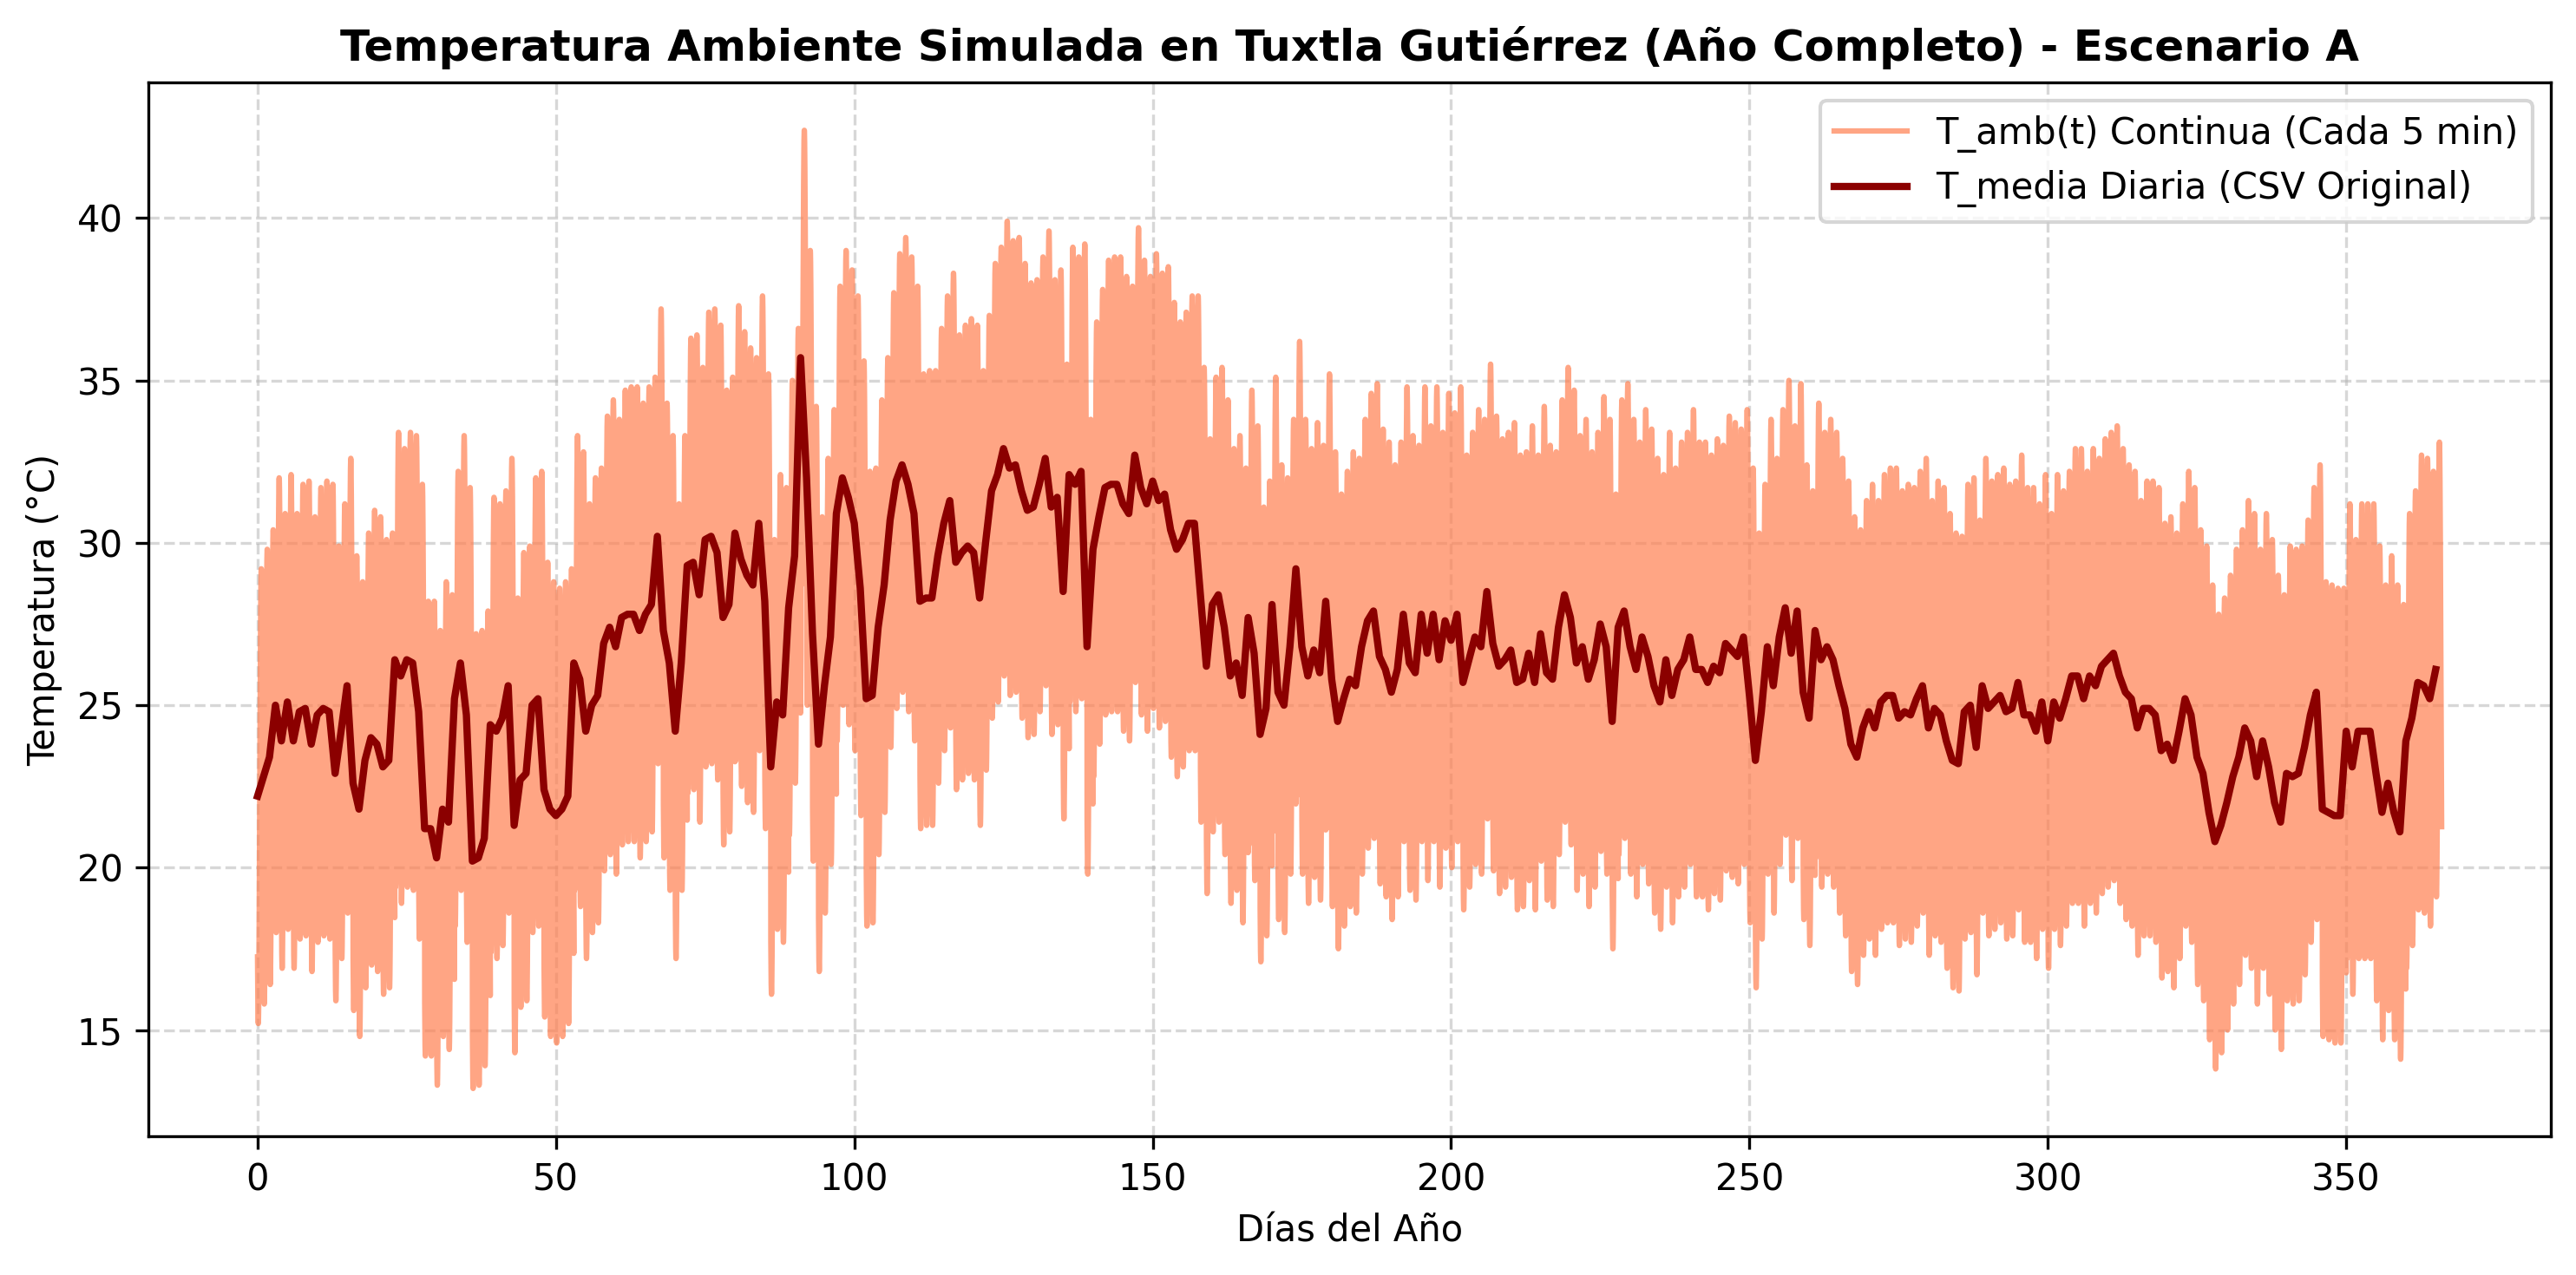

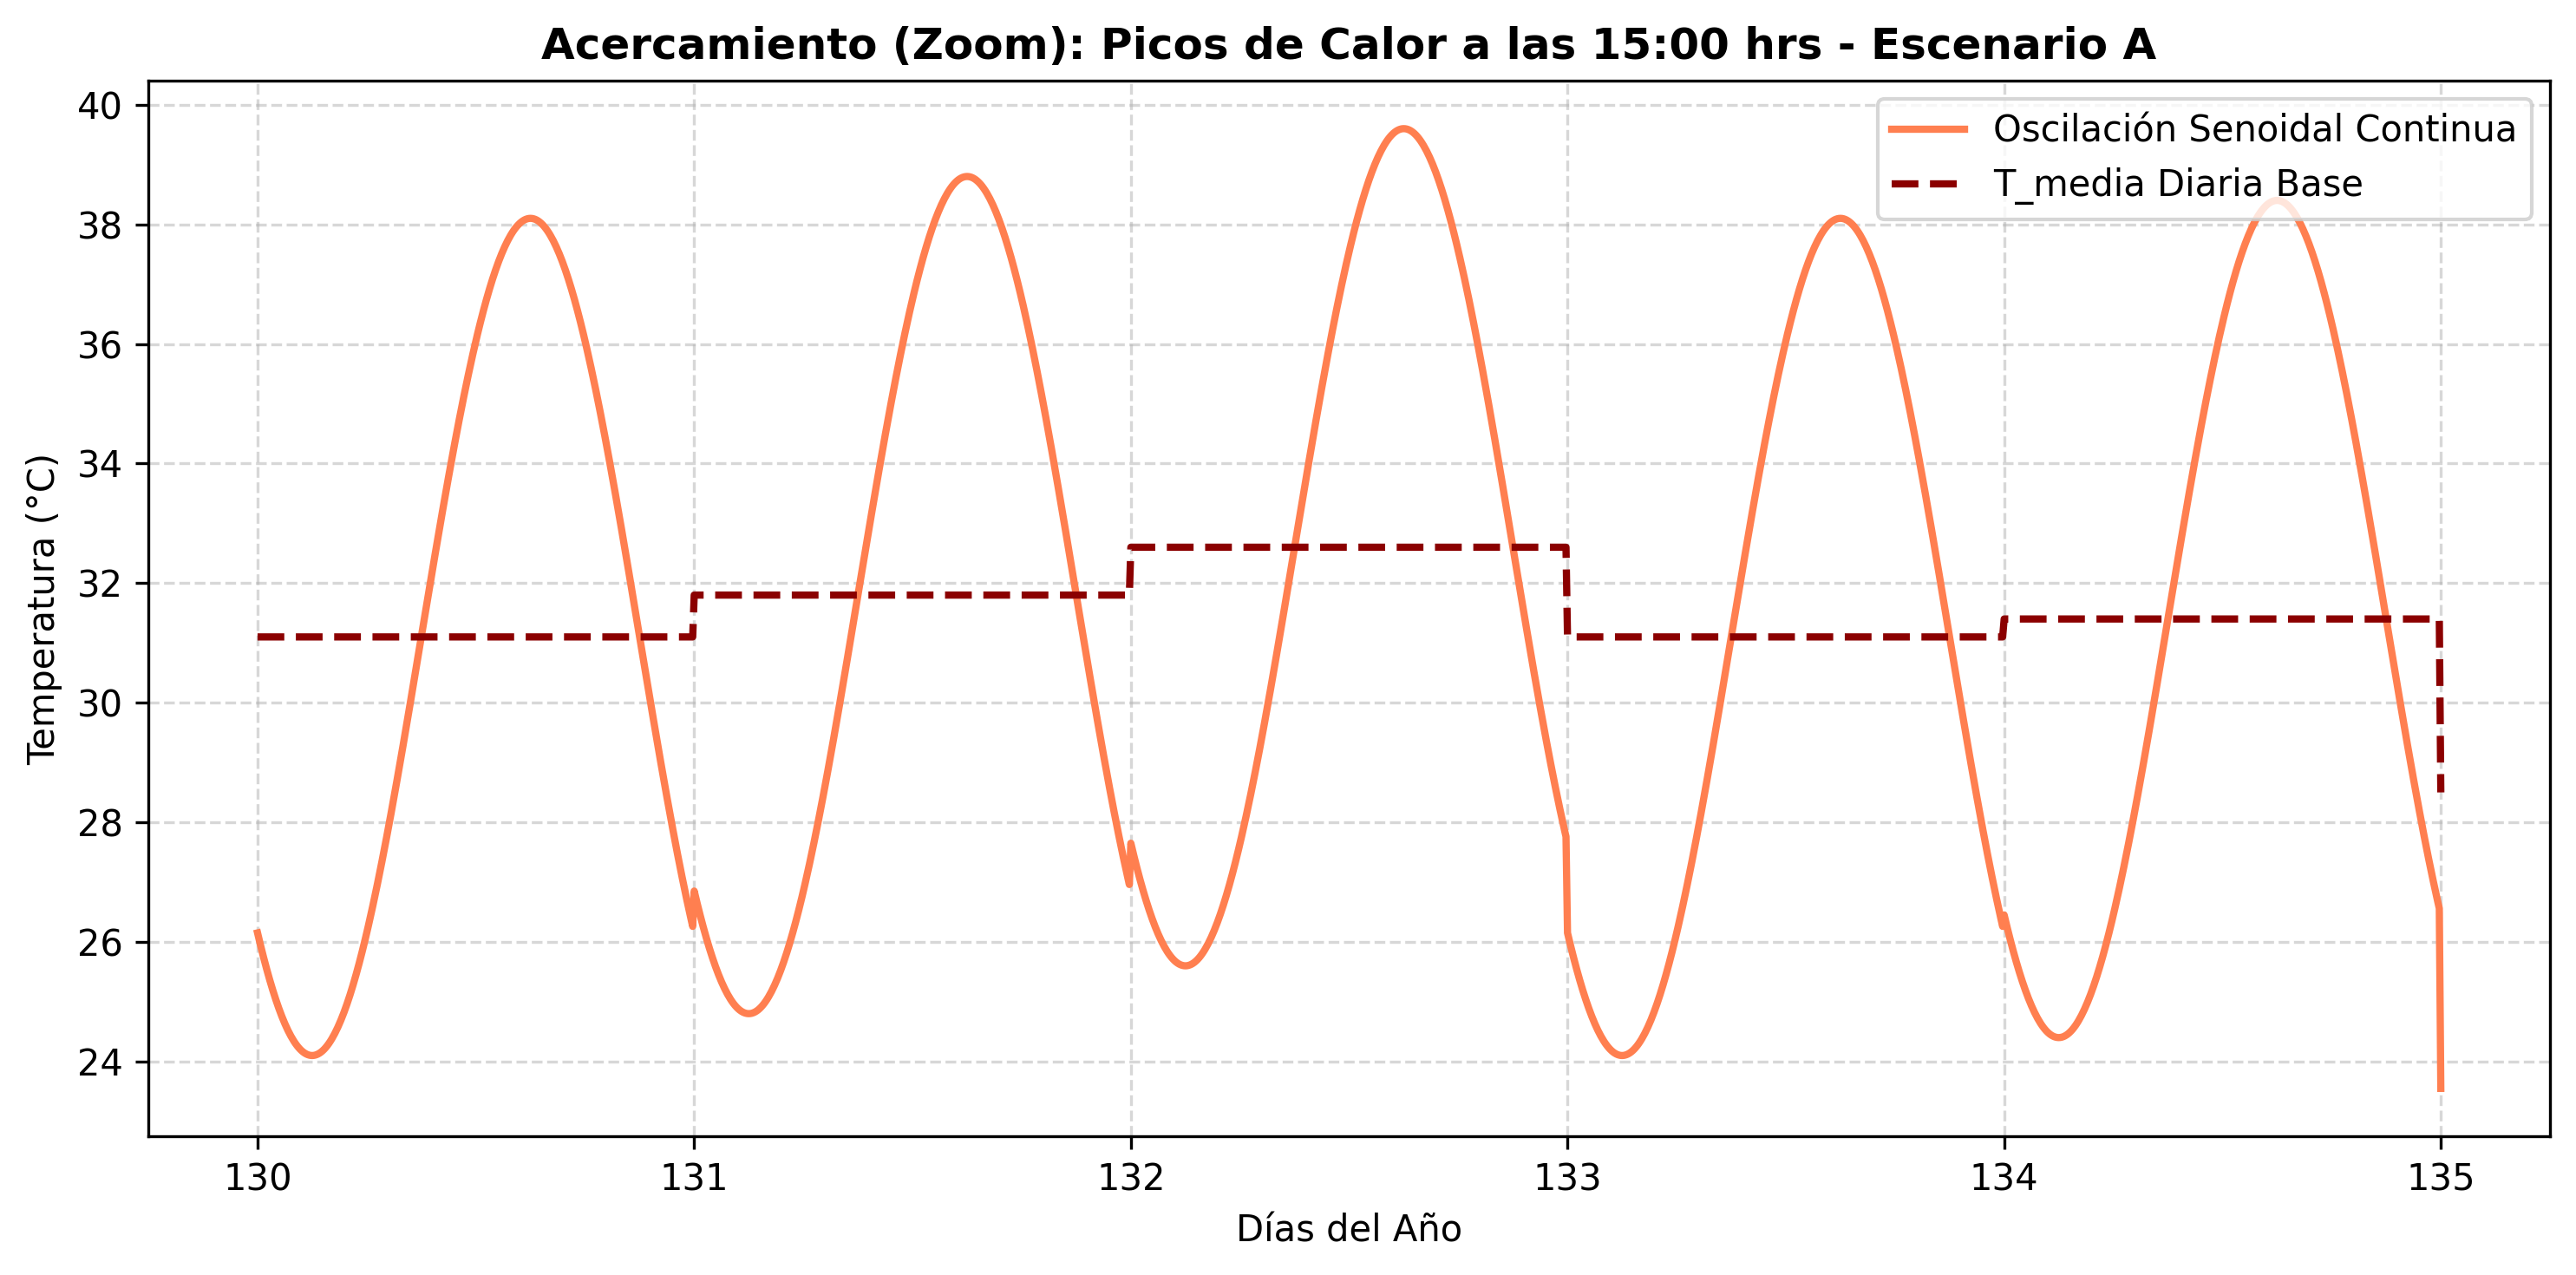

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. CARGA DE DATOS Y PREPARACIÓN DEL CALENDARIO LOGÍSTICO
ruta_csv = "/content/drive/MyDrive/CLIMA TUXLTA/CLIMA. TUXTLA/Clima de Tuxtla 2024.csv"
df = pd.read_csv(ruta_csv)

# Asegurar el formato de fecha y ordenar cronológicamente
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Definimos los días festivos oficiales de México en 2024
festivos_2024 = pd.to_datetime(['2024-01-01', '2024-02-05', '2024-03-18',
                                '2024-05-01', '2024-09-16', '2024-10-01',
                                '2024-11-18', '2024-12-25'])

# Creamos el arreglo booleano: True si es fin de semana (sábado=5, domingo=6) o festivo
df['es_fin_de_semana'] = df['date'].dt.dayofweek >= 5
df['es_festivo'] = df['date'].isin(festivos_2024)
df['es_inhabil'] = df['es_fin_de_semana'] | df['es_festivo']

# Extraemos la columna de temperatura e interpolamos los posibles valores nulos (NaNs)
df['tavg'] = df['tavg'].interpolate(method='linear')
T_diaria = df['tavg'].values               # Array de temperaturas diarias (366 días, 2024 fue bisiesto)
es_inhabil_diario = df['es_inhabil'].values # Array logístico de días inhábiles (366 días)

# 2. CREACIÓN DEL VECTOR DE TIEMPO (dt)
# Definimos el paso de integración en horas (5 minutos = 5/60 horas)
dt = 5 / 60.0
horas_totales = len(T_diaria) * 24
t_horas = np.arange(0, horas_totales, dt)

# 3. CONSTRUCCIÓN DE LA FUNCIÓN DETERMINISTA T_amb(t)
# Mapeamos la temperatura media a cada paso de 5 minutos
indices_dia = np.floor(t_horas / 24).astype(int)
indices_dia = np.clip(indices_dia, 0, len(T_diaria)-1) # Evitamos el desbordamiento de índice al final
T_media_expandida = T_diaria[indices_dia]

# Expandimos también el vector logístico para saber si cada paso de 5 min cae en día inhábil
es_inhabil_expandido = es_inhabil_diario[indices_dia]

# Sobreponemos la oscilación para capturar el estrés térmico a lo largo del día.
# Amplitud de 7°C, con el argumento del coseno ajustado (-15) para tener el pico a las 15:00 hrs.
amplitud_diurna = 7.0
T_amb_t = T_media_expandida + amplitud_diurna * np.cos(2 * np.pi * (t_horas - 15) / 24)

print(f"Pasos totales de simulación: {len(t_horas)} iteraciones de {dt*60:.0f} minutos.\n")

# 4. GRÁFICA DEL CLIMA
# --- GRÁFICA 1: Panorama Anual ---
plt.figure(figsize=(10, 5), dpi=300)
plt.plot(t_horas / 24, T_amb_t, color='coral', alpha=0.7, label='T_amb(t) Continua (Cada 5 min)')
plt.plot(np.arange(len(T_diaria)), T_diaria, color='darkred', lw=2, label='T_media Diaria (CSV Original)')
plt.title('Temperatura Ambiente Simulada en Tuxtla Gutiérrez (Año Completo) - Escenario A', fontweight='bold', fontsize=12)
plt.xlabel('Días del Año')
plt.ylabel('Temperatura (°C)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# Guardamos la imagen
plt.savefig('temp_anual_tuxtla_escenario_A.png', bbox_inches='tight', dpi=300)
plt.show()

# --- GRÁFICA 2: Zoom ---
dia_inicio_zoom = 130
dia_fin_zoom = 135
mascara_zoom = (t_horas >= dia_inicio_zoom * 24) & (t_horas <= dia_fin_zoom * 24)

plt.figure(figsize=(10, 5), dpi=300)
plt.plot(t_horas[mascara_zoom] / 24, T_amb_t[mascara_zoom], color='coral', lw=2, label='Oscilación Senoidal Continua')
plt.plot(t_horas[mascara_zoom] / 24, T_media_expandida[mascara_zoom], color='darkred', lw=2, linestyle='--', label='T_media Diaria Base')
plt.title('Acercamiento (Zoom): Picos de Calor a las 15:00 hrs - Escenario A', fontweight='bold', fontsize=12)
plt.xlabel('Días del Año')
plt.ylabel('Temperatura (°C)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# Guardamos la imagen
plt.savefig('temp_zoom_tuxtla_escenario_A.png', bbox_inches='tight', dpi=300)
plt.show()

## Celda 2: Calibración Física de la EDE y Reglas de la Clínica (Línea Base)

En esta sección definimos las constantes físicas del refrigerador y las reglas operativas de la clínica simulada.

1. **Parámetros Termodinámicos:** Asignamos los valores calibrados para el equipo Haier HBC-150 ($\kappa_{on}$, $\kappa_{off}$, $\sigma_{on}$, $\sigma_{off}$) y fijamos el termostato en 5°C.
2. **Cinética de Degradación:** Definimos las constantes de la ecuación de Arrhenius ($E_a$, factor $A$) para calcular el daño biológico por calor.
3. **Aperturas de Puerta:** Al ser el Escenario A (Control Absoluto), se simula la inactividad clínica total. Todas las aperturas de puerta (matutinas y vespertinas) están estrictamente prohibidas.

In [ ]:
# 1. PARÁMETROS TERMODINÁMICOS (HAIER HBC-150)
kappa_on = 0.1154   # Velocidad de enfriamiento activo (compresor)
kappa_off = 0.00232 # Pérdida térmica inercial (aislamiento en apagón)
theta_set = 5.0     # Termostato ideal OMS (°C)

sigma_on = 0.4804   # Volatilidad con motor encendido
sigma_off = 0.048   # Volatilidad pasiva en apagón

T_0 = 5.0           # Temperatura inicial de arranque

# 2. PARÁMETROS DEL DAÑO TÉRMICO (ARRHENIUS)
Ea = 85000.0        # Energía de activación (J/mol)
R_gas = 8.314       # Constante de los gases
A_factor = 1.2e13   # Factor pre-exponencial

# 3. LÓGICA DE APERTURAS DE PUERTA (ESCENARIO A - NULA)
hora_dia = t_horas % 24

# Sin aperturas matutinas
apertura_manana_fija = np.zeros_like(t_horas, dtype=bool)

# Sin aperturas aleatorias (Tarde y Resurtido)
lambda_tarde = np.zeros_like(t_horas)
lambda_resurtido = np.zeros_like(t_horas)

print("Parámetros termodinámicos y de Arrhenius cargados. Aperturas desactivadas (Escenario A).")

Parámetros termodinámicos y de Arrhenius cargados. Aperturas desactivadas (Escenario A).


## Celda 3: Parámetros del Suministro Eléctrico (CFE)

En esta celda modelamos el riesgo externo que sufre la red eléctrica. Como observamos en el análisis de datos, el clima afecta severamente la infraestructura, provocando que los apagones tengan una distribución anual asimétrica. Para simular esto en el centro de almacenamiento para vacunas, definimos dos funciones:

1. **Frecuencia de Apagones:** Programamos la función `tasa_cortes_cfe(t)`, que representa la intensidad $\lambda(t)$ de nuestro Proceso de Poisson No Homogéneo. Sumamos el riesgo base de fallas locales ($0.0667$) con dos campanas gaussianas que simulan los picos calibrados: el estrés por la ola de calor (centrado en el día 152, amplitud $0.2314$, varianza $4050$) y la temporada de tormentas (centrada en el día 244, amplitud $0.2048$, varianza $1800$).
2. **Duración de Apagones:** Programamos una función que devuelve los parámetros exactos $\mu$ y $\sigma$ de una distribución Log-Normal calibrada. El algoritmo evaluará en qué día del año se encuentra (Estabilidad, Calor o Lluvias) para asignar la duración correspondiente al apagón.

In [ ]:
# 1. MODELO DE ESTADO ELÉCTRICO S(t) - FRECUENCIA DE APAGONES

def tasa_cortes_cfe(dia_del_ano):
    """
    Intensidad diaria de fallas (Proceso de Poisson No Homogéneo).
    """
    # Riesgo base mínimo constante (mantenimiento o fallas locales)
    base = 0.0667

    # Pico 1: Temporada de calor extremo (Centro en el día 152, varianza 4050)
    k1 = 0.2314 * np.exp(-((dia_del_ano - 152)**2) / 4050)

    # Pico 2: Temporada de lluvias y tormentas (Centro en el día 244, varianza 1800)
    k2 = 0.2048 * np.exp(-((dia_del_ano - 244)**2) / 1800)

    return base + k1 + k2

# 2. DURACIÓN DEL APAGÓN - DISTRIBUCIÓN LOG-NORMAL

# Diccionario con los parámetros (mu, sigma) deducidos por el Método de Momentos.
parametros_duracion = {
    'Estabilidad': {'mu': 0.6766, 'sigma': 0.6202}, # Ene-Mar y Nov-Dic (Mantenimientos base)
    'Calor':       {'mu': 0.9627, 'sigma': 0.5106}, # Abr-Jul (Saturación térmica)
    'Lluvias':     {'mu': 0.4668, 'sigma': 0.3372}  # Ago-Oct (Tormentas rápidas)
}

def obtener_parametros_lognormal(dia_del_ano):
    """
    Revisa el día del año actual (1 a 366) y devuelve los parámetros de la
    distribución Log-Normal correspondiente a la temporada climática.
    """
    if 92 <= dia_del_ano <= 213:
        # Temporada: Abril - Julio (Estrés Térmico y Canícula)
        return parametros_duracion['Calor']['mu'], parametros_duracion['Calor']['sigma']

    elif 214 <= dia_del_ano <= 305:
        # Temporada: Agosto - Octubre (Lluvias y Huracanes)
        return parametros_duracion['Lluvias']['mu'], parametros_duracion['Lluvias']['sigma']

    else:
        # Temporada: Noviembre - Marzo (Estabilidad Invernal)
        return parametros_duracion['Estabilidad']['mu'], parametros_duracion['Estabilidad']['sigma']

print("Funciones y parámetros del suministro eléctrico (CFE) cargados (Escenario A).")

Funciones y parámetros del suministro eléctrico (CFE) cargados (Escenario A).


## Celda 4: Generación de Trayectorias de Red Eléctrica y Saltos (Línea Base)

En esta celda pre-calculamos de forma vectorizada los dos procesos estocásticos externos que perturbarán a nuestra Ecuación Diferencial Estocástica (EDE) en la simulación:

1. **Estado Eléctrico $S(t)$:** Recorremos todos los días del año. Para cada día, hacemos un muestreo de Poisson utilizando nuestra tasa de fallas de la CFE ($\lambda(t)$). Si ocurre un apagón, calculamos su duración utilizando la distribución Log-Normal calibrada a esa temporada climática y modificamos el vector $S(t)$ (cambiando su valor de 1 a 0 durante ese intervalo). Este vector equivale a la variable $\alpha(t)$ del modelo teórico.
2. **Proceso de Saltos (Aperturas):** Al ser el Escenario A (Control Absoluto), se simula un sistema sin intervención del personal. Por lo tanto, el vector que registra el ingreso de calor por aperturas de puerta será estrictamente cero durante todo el año.

In [ ]:
np.random.seed(42) # Fijamos semilla para que la prueba base sea reproducible

# 1. GENERACIÓN DE APAGONES - ESTADO ELÉCTRICO S(t)
# Inicializamos asumiendo que hay luz (1) todo el año
S_t = np.ones(len(t_horas))
dias_totales = int(np.ceil(t_horas[-1] / 24))

for dia in range(dias_totales):

    # Obtenemos la tasa de fallas de luz
    tasa_hoy = tasa_cortes_cfe(dia)

    # Proceso de Poisson:
    num_cortes = np.random.poisson(tasa_hoy)

    for _ in range(num_cortes):
        # Si hubo corte, decidimos a qué hora exacta del día empezó
        hora_inicio = (dia * 24) + np.random.uniform(0, 24)

        # Consultamos cuánto va a durar el apagón según la estación
        mu_ln, sigma_ln = obtener_parametros_lognormal(dia)
        duracion_horas = np.random.lognormal(mu_ln, sigma_ln)

        # Convertimos las horas a índices de nuestro vector de 5 minutos
        idx_inicio = int(hora_inicio / dt)
        idx_fin = int((hora_inicio + duracion_horas) / dt)

        # Apagamos el suministro (0) en ese intervalo
        if idx_inicio < len(S_t):
            idx_fin = min(idx_fin, len(S_t))
            S_t[idx_inicio:idx_fin] = 0

transiciones = np.sum(np.diff(S_t) == -1)
print(f"Trayectoria eléctrica S(t) generada. Ocurrieron {transiciones} apagones en el año.")

# 2. GENERACIÓN DEL PROCESO DE SALTOS (Escenario A)
# En el escenario de control absoluto no hay interacción humana.
Saltos_Termicos_t = np.zeros(len(t_horas))

aperturas_totales = 0
print(f"Vector de saltos generado. La puerta se abrió {aperturas_totales} veces (Línea Base).")

Trayectoria eléctrica S(t) generada. Ocurrieron 68 apagones en el año.
Vector de saltos generado. La puerta se abrió 0 veces (Línea Base).


## Celda 5: Resolución Numérica de la EDE y Dinámica Térmica (Línea Base)

En esta celda integramos paso a paso la Ecuación Diferencial Estocástica (EDE) para el escenario de control absoluto. Hacemos lo siguiente:

1. **Integración Numérica (Euler-Maruyama):** Utilizamos este esquema porque en nuestro modelo de Ornstein-Uhlenbeck, el coeficiente de difusión (volatilidad $\sigma$) es constante para cada régimen y no depende de la temperatura. Dado que su derivada es cero, el término de corrección del método de Milstein se anula, reduciéndose exactamente al esquema de Euler-Maruyama.
2. **Métricas de Seguridad (Excursiones y Tiempos):** El algoritmo cuenta cuántos eventos (cruces de línea) superaron el límite de 8°C o cayeron bajo 2°C. Además, convierte las iteraciones totales a horas físicas y porcentajes anuales para cuantificar exactamente el tiempo que el centro de almacenamiento para vacunas estuvo fuera de la norma.
3. **Visualización de la Dinámica Térmica:** Generamos el panorama térmico anual y un acercamiento completo a todo el mes de enero para observar el comportamiento termodinámico inicial.

Integrando la SDE con el esquema de Euler-Maruyama...
Integración completada exitosamente.

-> EXCURSIONES SOBRE 8°C:
   Eventos individuales: 40
   Tiempo acumulado: 22.25 horas (0.25% del año)
   Primer registro crítico en el Día 60.99

-> EXCURSIONES BAJO 2°C:
   Eventos individuales: 13
   Tiempo acumulado: 3.58 horas (0.04% del año)
   Primer registro crítico en el Día 110.25

=> TIEMPO TOTAL FUERA DE RANGO: 25.83 horas (0.29% del año)



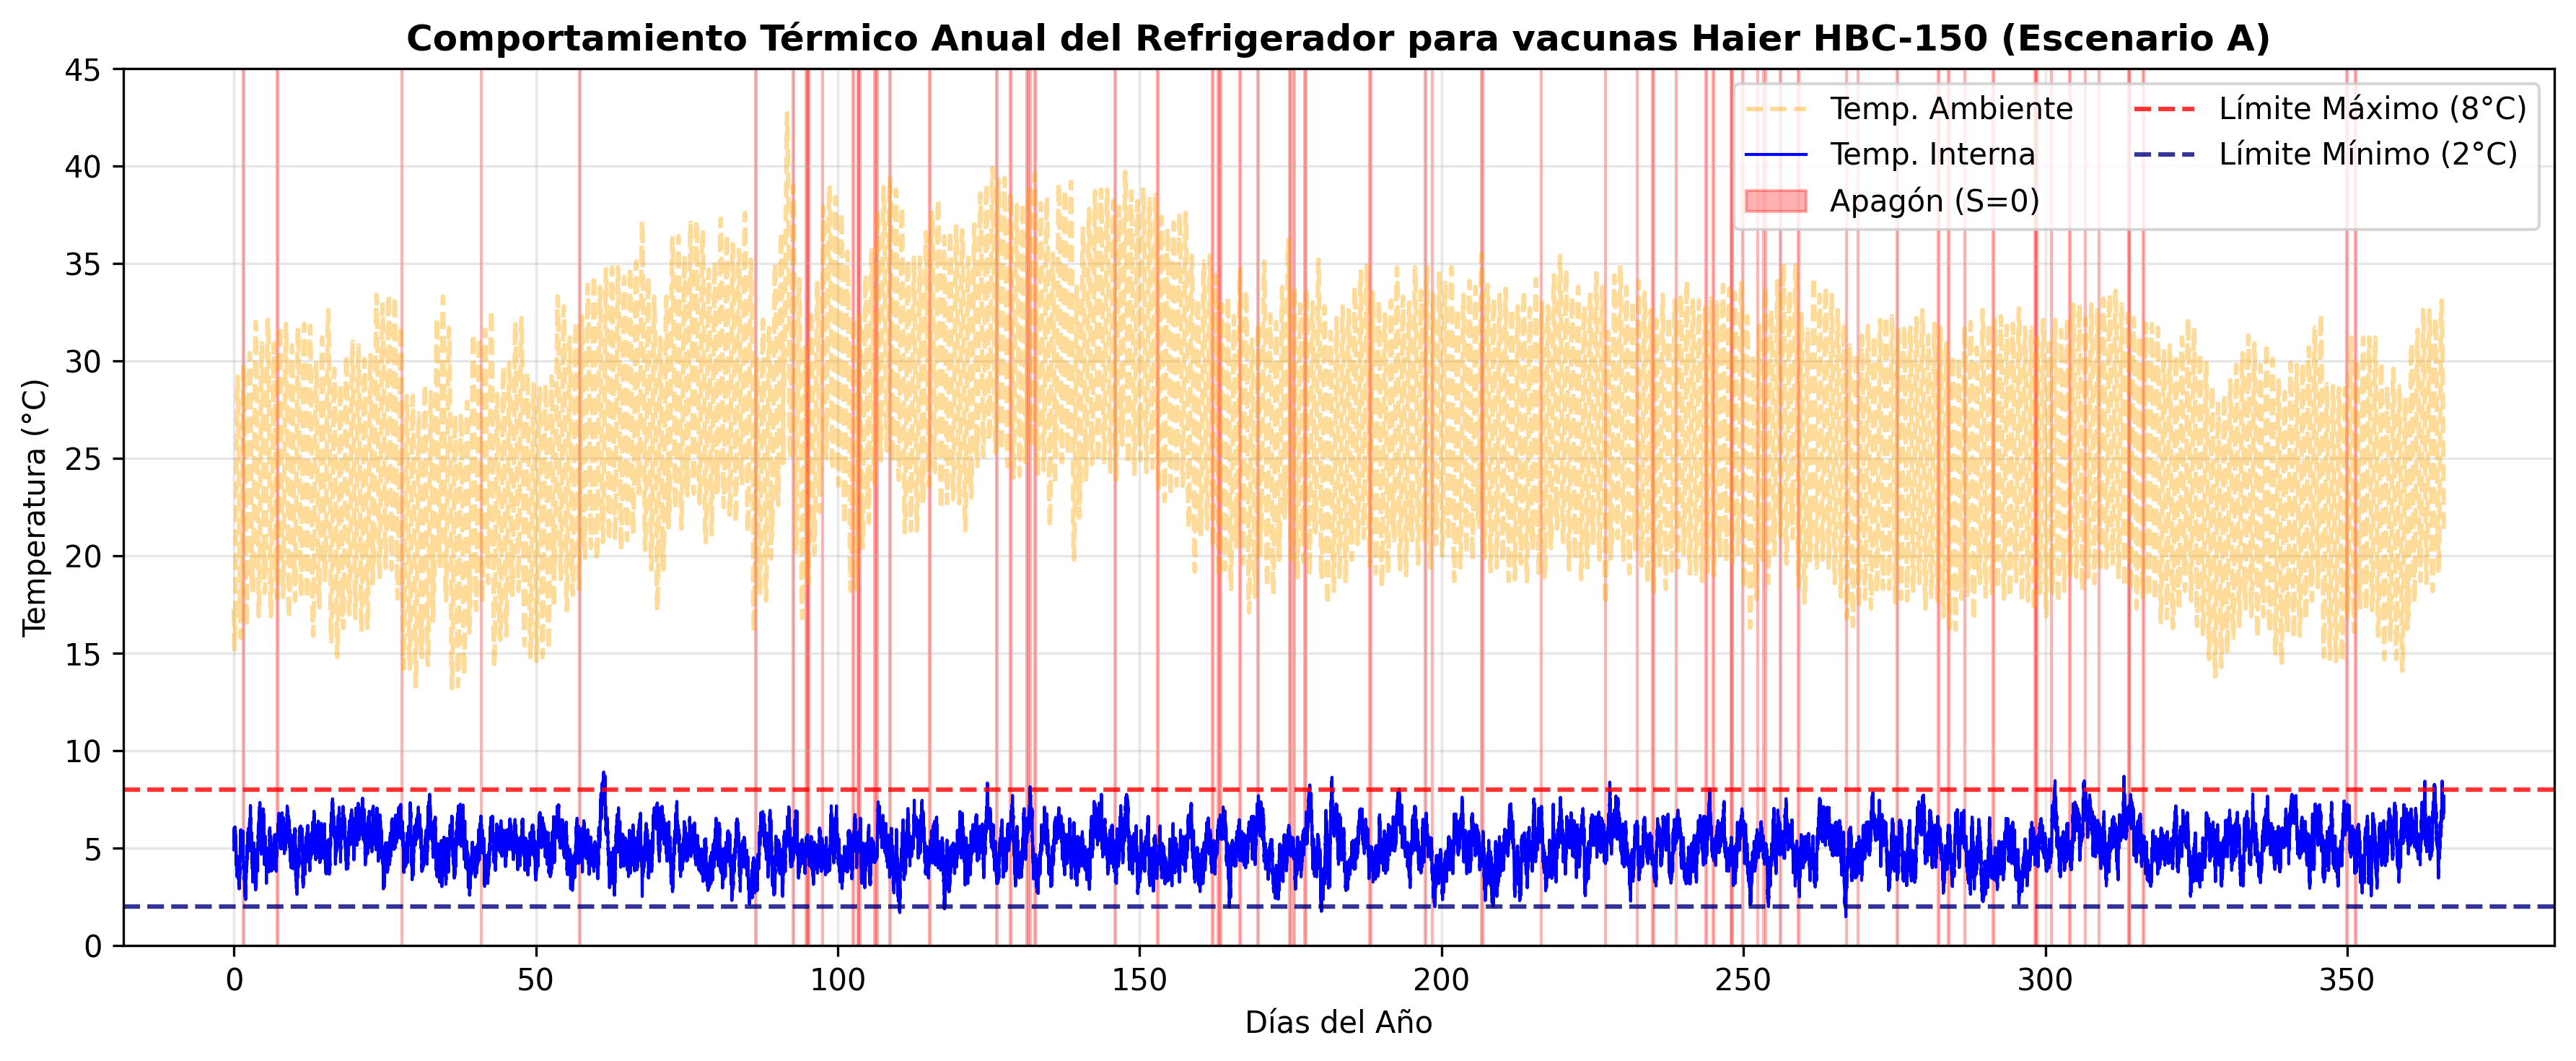

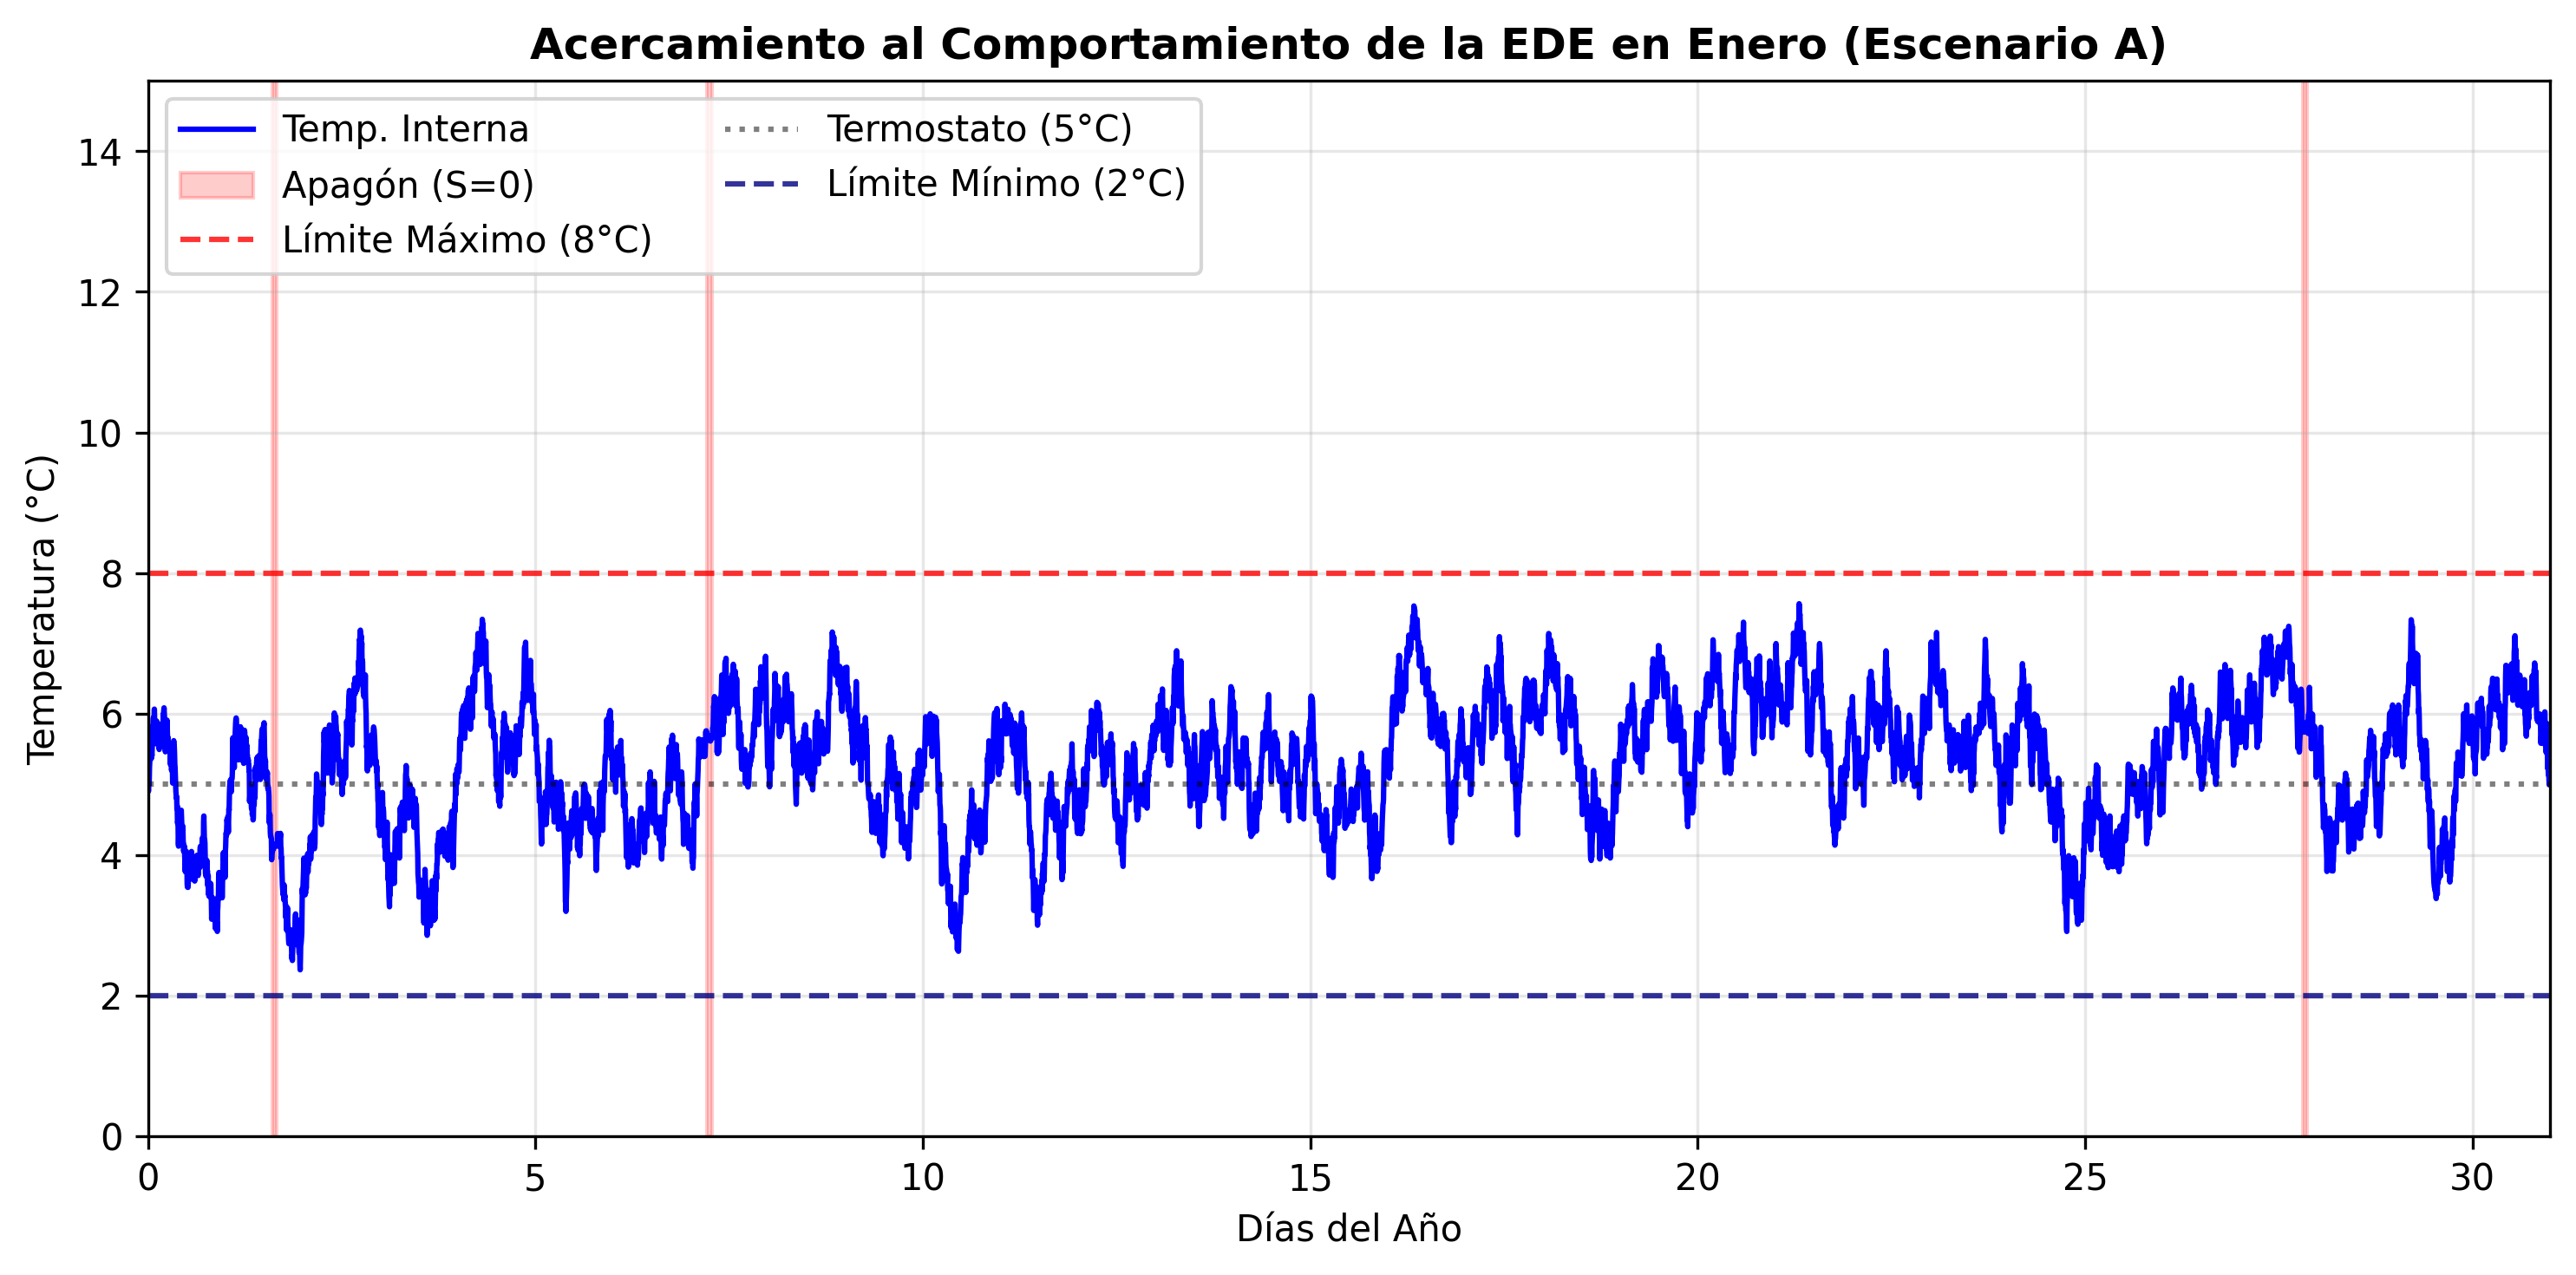

In [ ]:
# 1. PREPARACIÓN DE VECTORES PARA LA INTEGRACIÓN
np.random.seed(13) # Fijamos semilla para que la trayectoria sea comparable entre escenarios
X_t = np.zeros(len(t_horas))
X_t[0] = T_0                # Iniciamos en el termostato (5°C)

print("Integrando la SDE con el esquema de Euler-Maruyama...")

# 2. BUCLE DE INTEGRACIÓN NUMÉRICA
for i in range(1, len(t_horas)):
    # Incremento del Movimiento Browniano
    dW = np.sqrt(dt) * np.random.randn()

    # Evaluamos el régimen eléctrico (Regime-Switching)
    if S_t[i-1] == 1:
        # Régimen 1: Compresor operando
        drift = kappa_on * (theta_set - X_t[i-1]) * dt
        difusion = sigma_on * dW
        salto = Saltos_Termicos_t[i-1]
    else:
        # Régimen 2: Apagón
        drift = kappa_off * (T_amb_t[i-1] - X_t[i-1]) * dt
        difusion = sigma_off * dW
        salto = 0 # El centro de almacenamiento para vacunas no abre sus puertas sin luz

    # Euler-Maruyama
    X_t[i] = X_t[i-1] + drift + difusion + salto

# 3. MÉTRICAS DE EVENTOS Y TIEMPOS NORMATIVOS
sobrepasos_8 = X_t > 8.0
sobrepasos_2 = X_t < 2.0

# Contamos eventos lógicos (cruces) y el total de iteraciones (tiempo)
eventos_8 = np.sum((sobrepasos_8[1:] & ~sobrepasos_8[:-1]))
eventos_2 = np.sum((sobrepasos_2[1:] & ~sobrepasos_2[:-1]))

horas_8 = np.sum(sobrepasos_8) * dt
horas_2 = np.sum(sobrepasos_2) * dt
horas_totales_falla = horas_8 + horas_2
horas_ano = 366 * 24

print("Integración completada exitosamente.\n")
print(f"-> EXCURSIONES SOBRE 8°C:")
print(f"   Eventos individuales: {eventos_8}")
print(f"   Tiempo acumulado: {horas_8:.2f} horas ({horas_8/horas_ano*100:.2f}% del año)")
if eventos_8 > 0:
    print(f"   Primer registro crítico en el Día {t_horas[sobrepasos_8][0]/24:.2f}")

print(f"\n-> EXCURSIONES BAJO 2°C:")
print(f"   Eventos individuales: {eventos_2}")
print(f"   Tiempo acumulado: {horas_2:.2f} horas ({horas_2/horas_ano*100:.2f}% del año)")
if eventos_2 > 0:
    print(f"   Primer registro crítico en el Día {t_horas[sobrepasos_2][0]/24:.2f}")

print(f"\n=> TIEMPO TOTAL FUERA DE RANGO: {horas_totales_falla:.2f} horas ({horas_totales_falla/horas_ano*100:.2f}% del año)\n")

# 4. GRÁFICAS DE LA DINÁMICA TÉRMICA

# --- GRÁFICA 1: Panorama Anual ---
plt.figure(figsize=(12, 5), dpi=300)
plt.plot(t_horas/24, T_amb_t, color='orange', alpha=0.4, linestyle='--', label='Temp. Ambiente')
plt.plot(t_horas/24, X_t, color='blue', linewidth=1.0, label='Temp. Interna')
plt.fill_between(t_horas/24, 0, 45, where=(S_t==0), color='red', alpha=0.3, label='Apagón (S=0)')

plt.axhline(y=8.0, color='red', linestyle='--', alpha=0.8, label='Límite Máximo (8°C)')
plt.axhline(y=2.0, color='navy', linestyle='--', alpha=0.8, label='Límite Mínimo (2°C)')

plt.ylim(0, 45)
plt.ylabel('Temperatura (°C)')
plt.xlabel('Días del Año')
plt.title('Comportamiento Térmico Anual del Refrigerador para vacunas Haier HBC-150 (Escenario A)', fontweight='bold')
plt.legend(loc='upper right', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sde_anual_escenario_A.png', bbox_inches='tight', dpi=300)
plt.show()

# --- GRÁFICA 2: Zoom a Enero (31 días) ---
idx_start = 0
idx_end = int(31 * 24 / dt)

plt.figure(figsize=(10, 5), dpi=300)
plt.plot(t_horas[idx_start:idx_end]/24, X_t[idx_start:idx_end], color='blue', linewidth=1.5, label='Temp. Interna')

apagones_zoom = S_t[idx_start:idx_end]
plt.fill_between(t_horas[idx_start:idx_end]/24, 0, 15, where=(apagones_zoom==0), color='red', alpha=0.2, label='Apagón (S=0)')

# Sin aperturas en Escenario A
plt.axhline(y=8.0, color='red', linestyle='--', alpha=0.8, label='Límite Máximo (8°C)')
plt.axhline(y=5.0, color='black', linestyle=':', alpha=0.5, label='Termostato (5°C)')
plt.axhline(y=2.0, color='navy', linestyle='--', alpha=0.8, label='Límite Mínimo (2°C)')

plt.ylim(0, 15)
plt.xlim(0, 31)
plt.ylabel('Temperatura (°C)')
plt.xlabel('Días del Año')
plt.title('Acercamiento al Comportamiento de la EDE en Enero (Escenario A)', fontweight='bold')
plt.legend(loc='upper left', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sde_zoom_escenario_A.png', bbox_inches='tight', dpi=300)
plt.show()

## Celda 6: Análisis de Impacto Logístico (Inventario vs. Mermas)

En esta sección traducimos el daño térmico en pérdidas absolutas de inventario físico. Para ello creamos dos modelos:

1. **Modelo Logístico (Inventario $I_t$):** Al ser el escenario de Control Absoluto, el consumo operativo de vacunas es estrictamente cero ($D_A(t) = 0$). El inventario disminuirá exclusivamente si un apagón destruye las dosis. Si el inventario cae al punto de reorden (20%), simulamos la llegada del camión jurisdiccional que vuelve a llenar el centro de almacenamiento para vacunas a su capacidad máxima de 5,000 dosis.
2. **Cálculo de Dosis Perdidas:** La temperatura simulada por la EDE corresponde a la temperatura interna del refri. Sin embargo, el biológico líquido dentro de los frascos de vidrio posee inercia térmica, tardando aproximadamente 30 minutos en igualar la temperatura interna del refri. Por ello, el algoritmo aplica una tolerancia: la Ecuación de Arrhenius solo comienza a destruir el inventario si la temperatura permanece por encima de los 8°C de manera sostenida por más de 30 minutos (6 iteraciones continuas).
3. **Visualización:** Generamos una gráfica de doble eje para observar el nivel del inventario y la curva de dosis destruidas acumuladas.

Total de vacunas que ingresaron al centro de almacenamiento en el año: 5000 dosis.
Total de vacunas destruidas: 108 dosis.
Porcentaje de pérdida: 2.16%



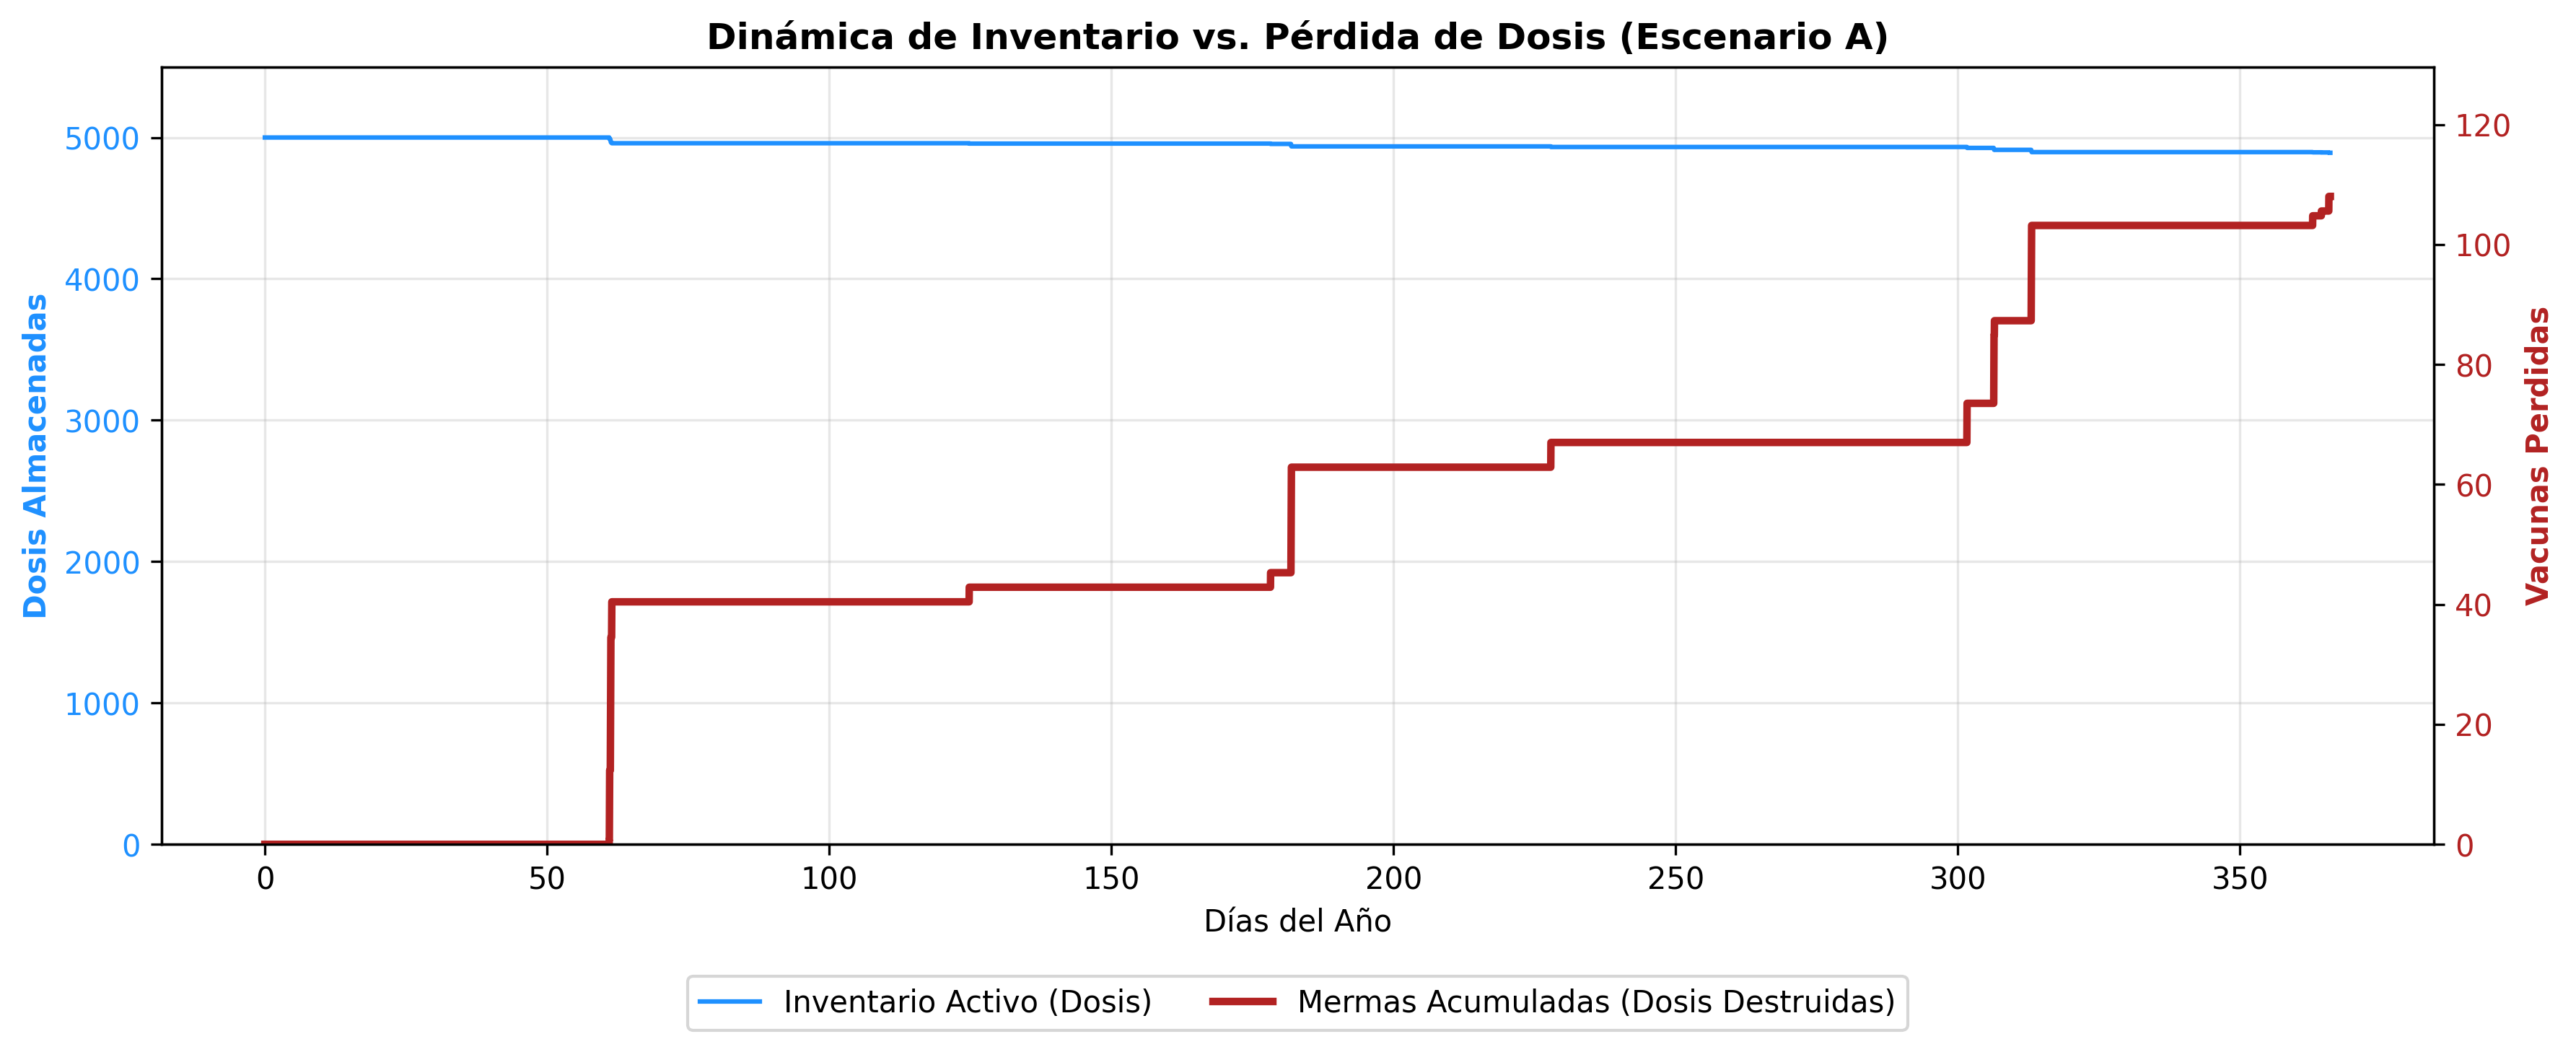

In [ ]:
# 1. PARÁMETROS DEL INVENTARIO LOGÍSTICO
capacidad_maxima = 5000.0  # Dosis máximas en el volumen útil del Haier HBC-150
punto_reorden = 1000.0     # Stock de seguridad (20%)

# Consumo diario base por mes (Ene a Dic)
consumo_diario_mes = [65, 110, 87, 65, 110, 65, 65, 65, 76, 163, 130, 87]

I_t = np.zeros(len(t_horas))
dosis_perdidas_dt = np.zeros(len(t_horas))

I_t[0] = capacidad_maxima
total_dosis_ingresadas = capacidad_maxima

# 2. BUCLE DINÁMICO: CONSUMO + MERMAS + REABASTECIMIENTO
tiempo_sobre_8 = 0  # Contador para la inercia térmica del frasco
tolerancia_pasos = 6 # 30 minutos (6 pasos de 5 min) de resistencia física

for i in range(1, len(t_horas)):
    inventario_actual = I_t[i-1]

    # A. Consumo de vacunas
    # Escenario A: Demanda nula, no hay extracciones.

    # B. Daño Térmico con Inercia del Frasco
    if X_t[i] > 8.0:
        tiempo_sobre_8 += 1
        # Solo empieza a hacer daño si el calor lleva más de 30 minutos sostenidos
        if tiempo_sobre_8 > tolerancia_pasos:
            T_kelvin = X_t[i] + 273.15
            k_t = A_factor * np.exp(-Ea / (R_gas * T_kelvin))
            fraccion_perdida = 1 - np.exp(-k_t * dt)
            merma_instante = inventario_actual * fraccion_perdida
        else:
            merma_instante = 0.0
    else:
        tiempo_sobre_8 = 0 # El equipo se enfrió, el contador se reinicia
        merma_instante = 0.0

    dosis_perdidas_dt[i] = merma_instante
    inventario_actual -= merma_instante

    # C. Reabastecimiento automático
    if inventario_actual <= punto_reorden:
        dosis_a_pedir = capacidad_maxima - inventario_actual
        total_dosis_ingresadas += dosis_a_pedir
        inventario_actual = capacidad_maxima

    I_t[i] = inventario_actual

# 3. RESULTADOS NUMÉRICOS
merma_acumulada_t = np.cumsum(dosis_perdidas_dt)
porcentaje_perdida = (merma_acumulada_t[-1] / total_dosis_ingresadas) * 100

print(f"Total de vacunas que ingresaron al centro de almacenamiento en el año: {total_dosis_ingresadas:.0f} dosis.")
print(f"Total de vacunas destruidas: {merma_acumulada_t[-1]:.0f} dosis.")
print(f"Porcentaje de pérdida: {porcentaje_perdida:.2f}%\n")

# 4. VISUALIZACIÓN LOGÍSTICA
plt.figure(figsize=(12, 5), dpi=300)

ax1 = plt.gca()
ax1.plot(t_horas/24, I_t, label='Inventario Activo (Dosis)', color='dodgerblue', linewidth=1.5)
ax1.set_xlabel('Días del Año')
ax1.set_ylabel('Dosis Almacenadas', color='dodgerblue', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='dodgerblue')
ax1.set_ylim(0, capacidad_maxima * 1.1)

ax2 = ax1.twinx()
ax2.plot(t_horas/24, merma_acumulada_t, label='Mermas Acumuladas (Dosis Destruidas)', color='firebrick', linewidth=2.5)
ax2.set_ylabel('Vacunas Perdidas', color='firebrick', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='firebrick')

max_merma_plot = np.max(merma_acumulada_t)
if max_merma_plot > 0:
    ax2.set_ylim(0, max_merma_plot * 1.2)
else:
    ax2.set_ylim(0, 10)

plt.title('Dinámica de Inventario vs. Pérdida de Dosis (Escenario A)', fontweight='bold', fontsize=12)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('inventario_vs_mermas_escenario_A.png', bbox_inches='tight', dpi=300)
plt.show()

## Celda 7: Simulación de Montecarlo

En esta sección consolidamos las dinámicas (térmica, eléctrica y logística) dentro de la función `simular_un_ano()`. El objetivo es generar una trayectoria completa en cuestión de segundos.

Para no depender de un solo escenario, aplicaremos el algoritmo de **Montecarlo con 5,000 simulaciones**. En cada iteración, el algoritmo extraerá y almacenará una amplia cantidad de métricas estadísticas sin conservar los arreglos gigantes de memoria (para evitar el desbordamiento de la RAM):
*   **Termodinámica:** Horas acumuladas y conteo de excursiones fuera de rango ($>8^\circ\text{C}$, $<2^\circ\text{C}$, y el riesgo crítico de congelación $<0^\circ\text{C}$).
*   **Logística y Riesgo:** El día exacto en que ocurrió la primera falla, el total de dosis destruidas, el porcentaje anual de pérdida y la merma estratificada por mes (para evaluar la estacionalidad del riesgo).

In [ ]:
import time

# 1. FUNCIÓN PRINCIPAL DE SIMULACIÓN ANUAL
def simular_un_ano(semilla, guardar_vectores=False):
    np.random.seed(semilla)

    # Inicialización
    S_t = np.ones(len(t_horas))
    I_t = np.zeros(len(t_horas))
    dosis_perdidas_dt = np.zeros(len(t_horas))
    merma_por_mes = np.zeros(12)

    inventario_actual = capacidad_maxima
    total_dosis_ingresadas = capacidad_maxima
    dias_totales = int(np.ceil(t_horas[-1] / 24))

    # A. Generación de Apagones
    for dia in range(dias_totales):
        num_cortes = np.random.poisson(tasa_cortes_cfe(dia))
        for _ in range(num_cortes):
            hora_inicio = (dia * 24) + np.random.uniform(0, 24)
            mu_ln, sigma_ln = obtener_parametros_lognormal(dia)
            duracion_horas = np.random.lognormal(mu_ln, sigma_ln)

            idx_inicio = int(hora_inicio / dt)
            idx_fin = int((hora_inicio + duracion_horas) / dt)
            if idx_inicio < len(S_t):
                idx_fin = min(idx_fin, len(S_t))
                S_t[idx_inicio:idx_fin] = 0

    # B. Generación de Aperturas (Escenario A = Nulas)
    dN_t_total = np.zeros(len(t_horas))
    Saltos_Termicos_t = np.zeros(len(t_horas))

    # C. Integración SDE
    X_t = np.zeros(len(t_horas))
    X_t[0] = T_0
    dW_vec = np.sqrt(dt) * np.random.randn(len(t_horas))

    tiempo_sobre_8 = 0
    tolerancia_pasos = 6 # Inercia térmica (30 min)

    for i in range(1, len(t_horas)):
        if S_t[i-1] == 1:
            drift = kappa_on * (theta_set - X_t[i-1]) * dt
            difusion = sigma_on * dW_vec[i]
            salto = Saltos_Termicos_t[i-1]
        else:
            drift = kappa_off * (T_amb_t[i-1] - X_t[i-1]) * dt
            difusion = sigma_off * dW_vec[i]
            salto = 0

        X_t[i] = X_t[i-1] + drift + difusion + salto

        # D. Lógica de Merma y Arrhenius
        if X_t[i] > 8.0:
            tiempo_sobre_8 += 1
            if tiempo_sobre_8 > tolerancia_pasos:
                T_kelvin = X_t[i] + 273.15
                k_t = A_factor * np.exp(-Ea / (R_gas * T_kelvin))
                fraccion_perdida = 1 - np.exp(-k_t * dt)
                merma_instante = inventario_actual * fraccion_perdida
            else:
                merma_instante = 0.0
        else:
            tiempo_sobre_8 = 0
            merma_instante = 0.0

        dosis_perdidas_dt[i] = merma_instante
        inventario_actual -= merma_instante

        dia_actual = int(t_horas[i] // 24)
        mes_actual = min(int((dia_actual % 366) / 30.5), 11)
        merma_por_mes[mes_actual] += merma_instante

        # E. Reabastecimiento
        if inventario_actual <= punto_reorden:
            total_dosis_ingresadas += (capacidad_maxima - inventario_actual)
            inventario_actual = capacidad_maxima

        I_t[i] = inventario_actual

    # F. Extracción de Métricas Estadísticas
    sobrepasos_8 = X_t > 8.0
    sobrepasos_2 = X_t < 2.0
    sobrepasos_0 = X_t < 0.0

    horas_8 = np.sum(sobrepasos_8) * dt
    horas_2 = np.sum(sobrepasos_2) * dt
    horas_0 = np.sum(sobrepasos_0) * dt
    horas_ano = len(t_horas) * dt

    resultado = {
        'merma_anual': np.sum(dosis_perdidas_dt),
        'porcentaje_perdida': (np.sum(dosis_perdidas_dt) / total_dosis_ingresadas) * 100,
        'dosis_totales_ingresadas': total_dosis_ingresadas,
        'total_apagones': np.sum(np.diff(S_t) == -1),
        'total_aperturas': np.sum(dN_t_total),
        'merma_por_mes': merma_por_mes,
        'eventos_8': np.sum((sobrepasos_8[1:] & ~sobrepasos_8[:-1])),
        'eventos_2': np.sum((sobrepasos_2[1:] & ~sobrepasos_2[:-1])),
        'eventos_0': np.sum((sobrepasos_0[1:] & ~sobrepasos_0[:-1])),
        'horas_8': horas_8,
        'horas_2': horas_2,
        'horas_0': horas_0,
        'porcentaje_horas_8': (horas_8 / horas_ano) * 100,
        'porcentaje_horas_2': (horas_2 / horas_ano) * 100,
        'porcentaje_horas_0': (horas_0 / horas_ano) * 100,
        'primer_dia_8': (np.where(sobrepasos_8)[0][0] * dt)/24 if np.any(sobrepasos_8) else np.nan,
        'primer_dia_2': (np.where(sobrepasos_2)[0][0] * dt)/24 if np.any(sobrepasos_2) else np.nan,
        'primer_dia_0': (np.where(sobrepasos_0)[0][0] * dt)/24 if np.any(sobrepasos_0) else np.nan
    }

    # Guardamos vectores completos solo en las primeras corridas para graficar después
    if guardar_vectores:
        resultado['trayectoria_merma'] = np.cumsum(dosis_perdidas_dt)
        resultado['X_t'] = np.copy(X_t)

    return resultado

# 2. EJECUCIÓN DEL BUCLE DE MONTECARLO
N_SIMULACIONES = 5000
resultados_mc = []

print(f"Iniciando Montecarlo con {N_SIMULACIONES} trayectorias...")
inicio_tiempo = time.time()

for sim in range(N_SIMULACIONES):
    # Guardamos la trayectoria completa solo para los primeros 30 años simulados
    guardar = True if sim < 30 else False
    resultado = simular_un_ano(semilla=sim + 42, guardar_vectores=guardar)
    resultados_mc.append(resultado)

    if (sim + 1) % 500 == 0:
        print(f"Progreso: {sim + 1} / {N_SIMULACIONES} años simulados.")

tiempo_total = time.time() - inicio_tiempo
print(f"¡Simulación Montecarlo completada en {tiempo_total/60:.2f} minutos!")

Iniciando Montecarlo con 5000 trayectorias...
Progreso: 500 / 5000 años simulados.
Progreso: 1000 / 5000 años simulados.
Progreso: 1500 / 5000 años simulados.
Progreso: 2000 / 5000 años simulados.
Progreso: 2500 / 5000 años simulados.
Progreso: 3000 / 5000 años simulados.
Progreso: 3500 / 5000 años simulados.
Progreso: 4000 / 5000 años simulados.
Progreso: 4500 / 5000 años simulados.
Progreso: 5000 / 5000 años simulados.
¡Simulación Montecarlo completada en 18.15 minutos!


## Celda 8: Extracción de Estadísticas y Análisis de Riesgo (Línea Base)

Una vez completadas las 5,000 simulaciones de Montecarlo, procedemos a extraer las métricas operativas y termodinámicas de todos los años generados para cuantificar el verdadero nivel de riesgo al que está expuesto el biológico en un escenario de inactividad.

1. **Tabla Resumen de Riesgo:** Extraemos las estadísticas descriptivas (promedios, medianas y el intervalo empírico del 95%) para las horas y porcentajes de excursión térmica ($>8^\circ\text{C}$, $<2^\circ\text{C}$ y $<0^\circ\text{C}$), el total de eventos, y el día promedio en el que ocurre la primera falla.
2. **Abanico de Trayectorias:** Visualizamos una sub-muestra de 30 años para observar cómo los apagones genera distintos niveles de daño acumulado sin intervención humana.
3. **Análisis Estacional:** A través de gráficos de barras (promedio y mediana mensual), cruzamos la vulnerabilidad climática contra la logística, permitiéndonos aislar en qué meses el riesgo termodinámico es más severo.
4. **Distribución del Riesgo Operativo:** Construimos el histograma del porcentaje de mermas (marcando la media, mediana y percentiles de riesgo) y un diagrama de caja (*boxplot*) ajustado, el cual nos servirá para comparar visualmente la varianza de este escenario contra los escenarios de intervención operativa.

 TABLA RESUMEN DE RIESGO OPERATIVO Y TERMODINÁMICO (ESCENARIO A) 
Trayectorias Simuladas: 5000 años
Apagones promedio: 64.3 por año
Aperturas promedio: 0 por año
---------------------------------------------------------------------------
MÉTRICAS TERMODINÁMICAS (Excursiones Térmicas)

 -> EXCURSIONES SOBRE 8°C:
    Eventos anuales  : Promedio 26.4 | Mediana 25 | Int. 95% [9, 51]
    Tiempo acumulado : Promedio 12.6 h (0.14%) | Mediana 11.4 h (0.13%) | Int. 95% [2.7 h, 28.3 h]
    Primer registro  : Promedio Día 38 | Mediana Día 26 | Int. 95% [Día 1, Día 137]

 -> EXCURSIONES BAJO 2°C:
    Eventos anuales  : Promedio 25.2 | Mediana 24 | Int. 95% [8, 48]
    Tiempo acumulado : Promedio 11.8 h (0.13%) | Mediana 10.8 h (0.12%) | Int. 95% [2.4 h, 26.5 h]
    Primer registro  : Promedio Día 38 | Mediana Día 27 | Int. 95% [Día 1, Día 145]

 -> CONGELACIÓN (BAJO 0°C):
    Eventos anuales  : Promedio 0.0 | Mediana 0 | Int. 95% [0, 0]
    Tiempo acumulado : Promedio 0.0 h (0.00%) | Mediana 0.0 h

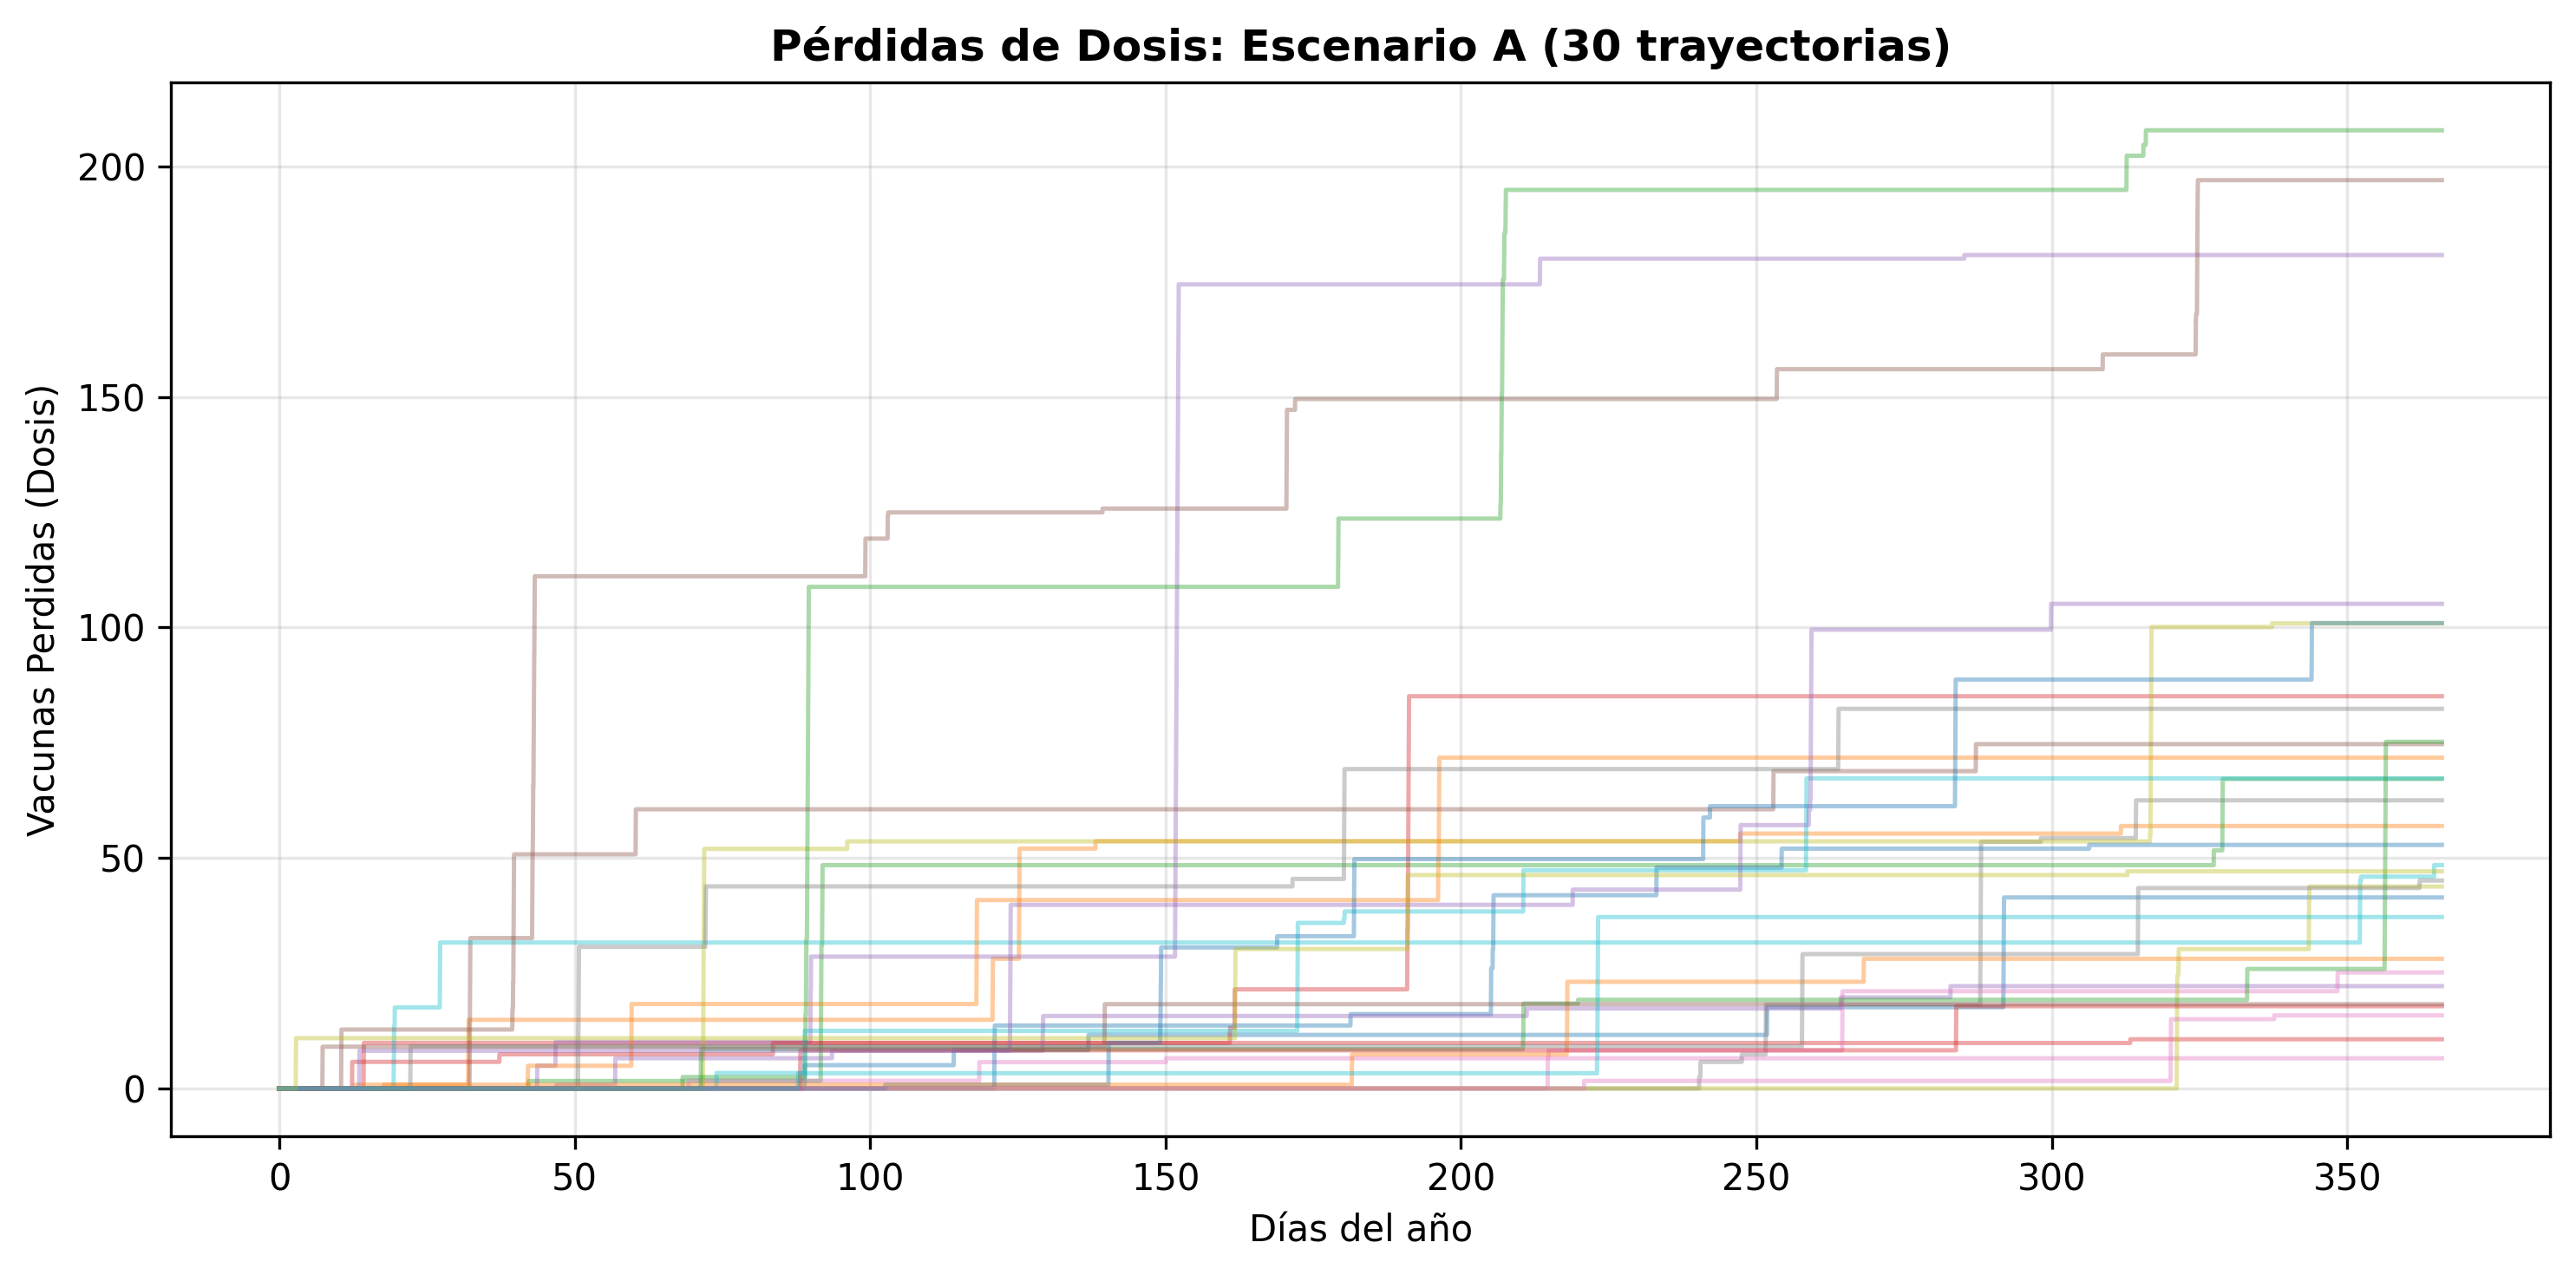

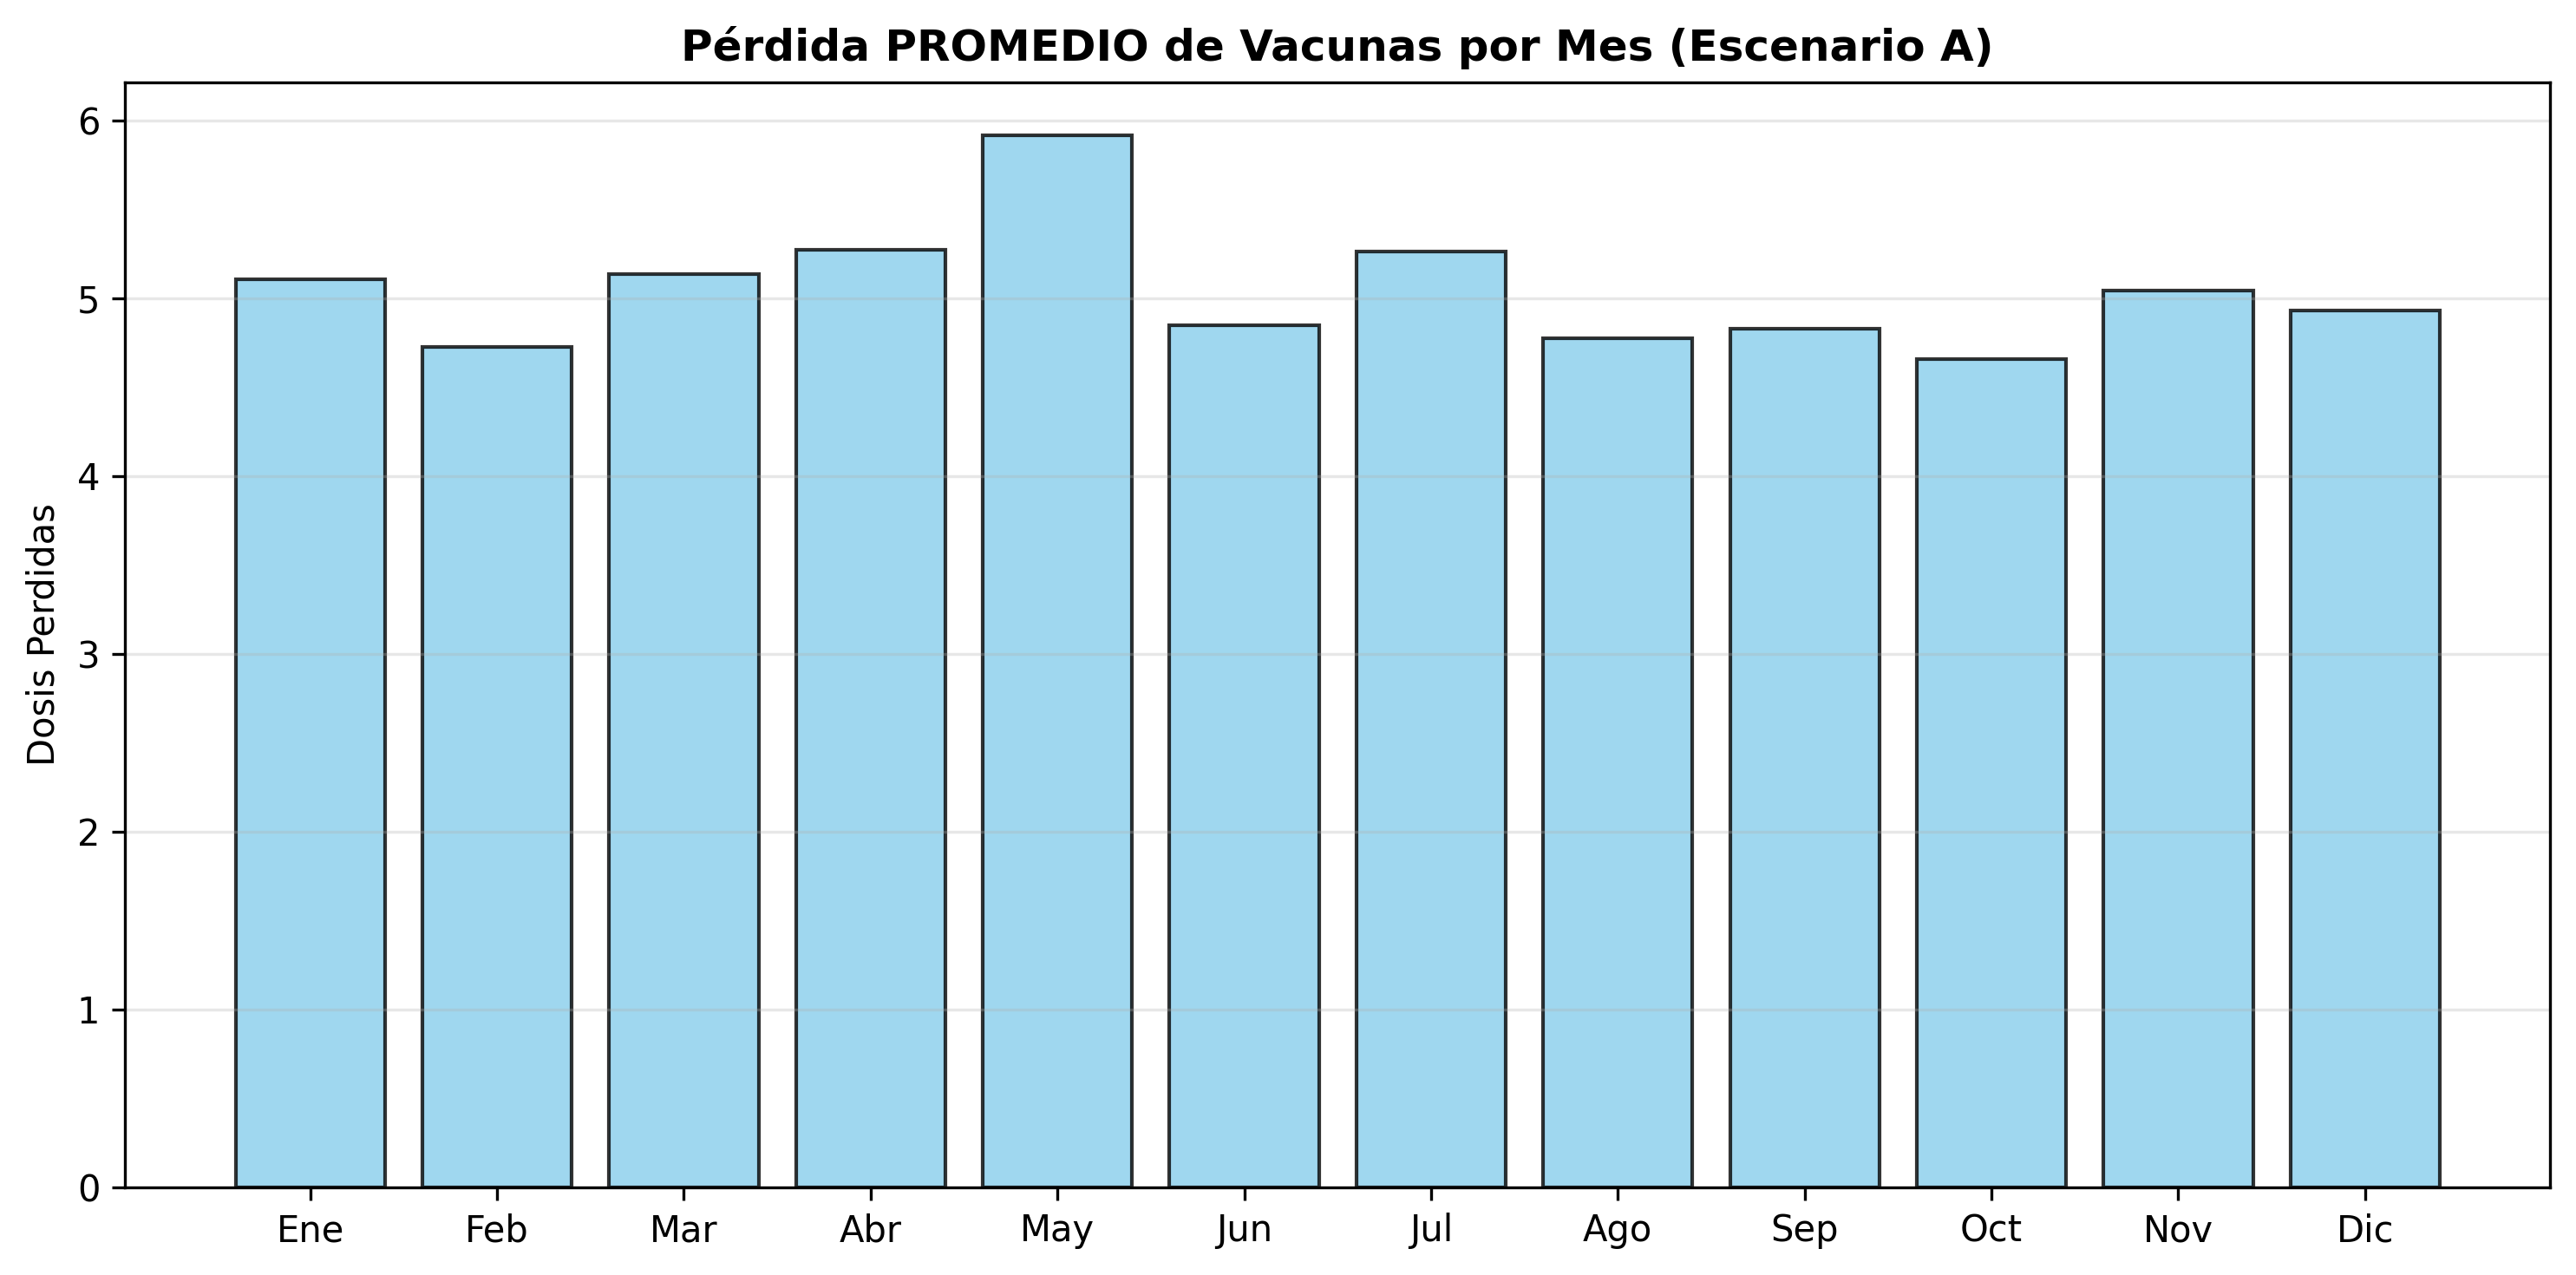

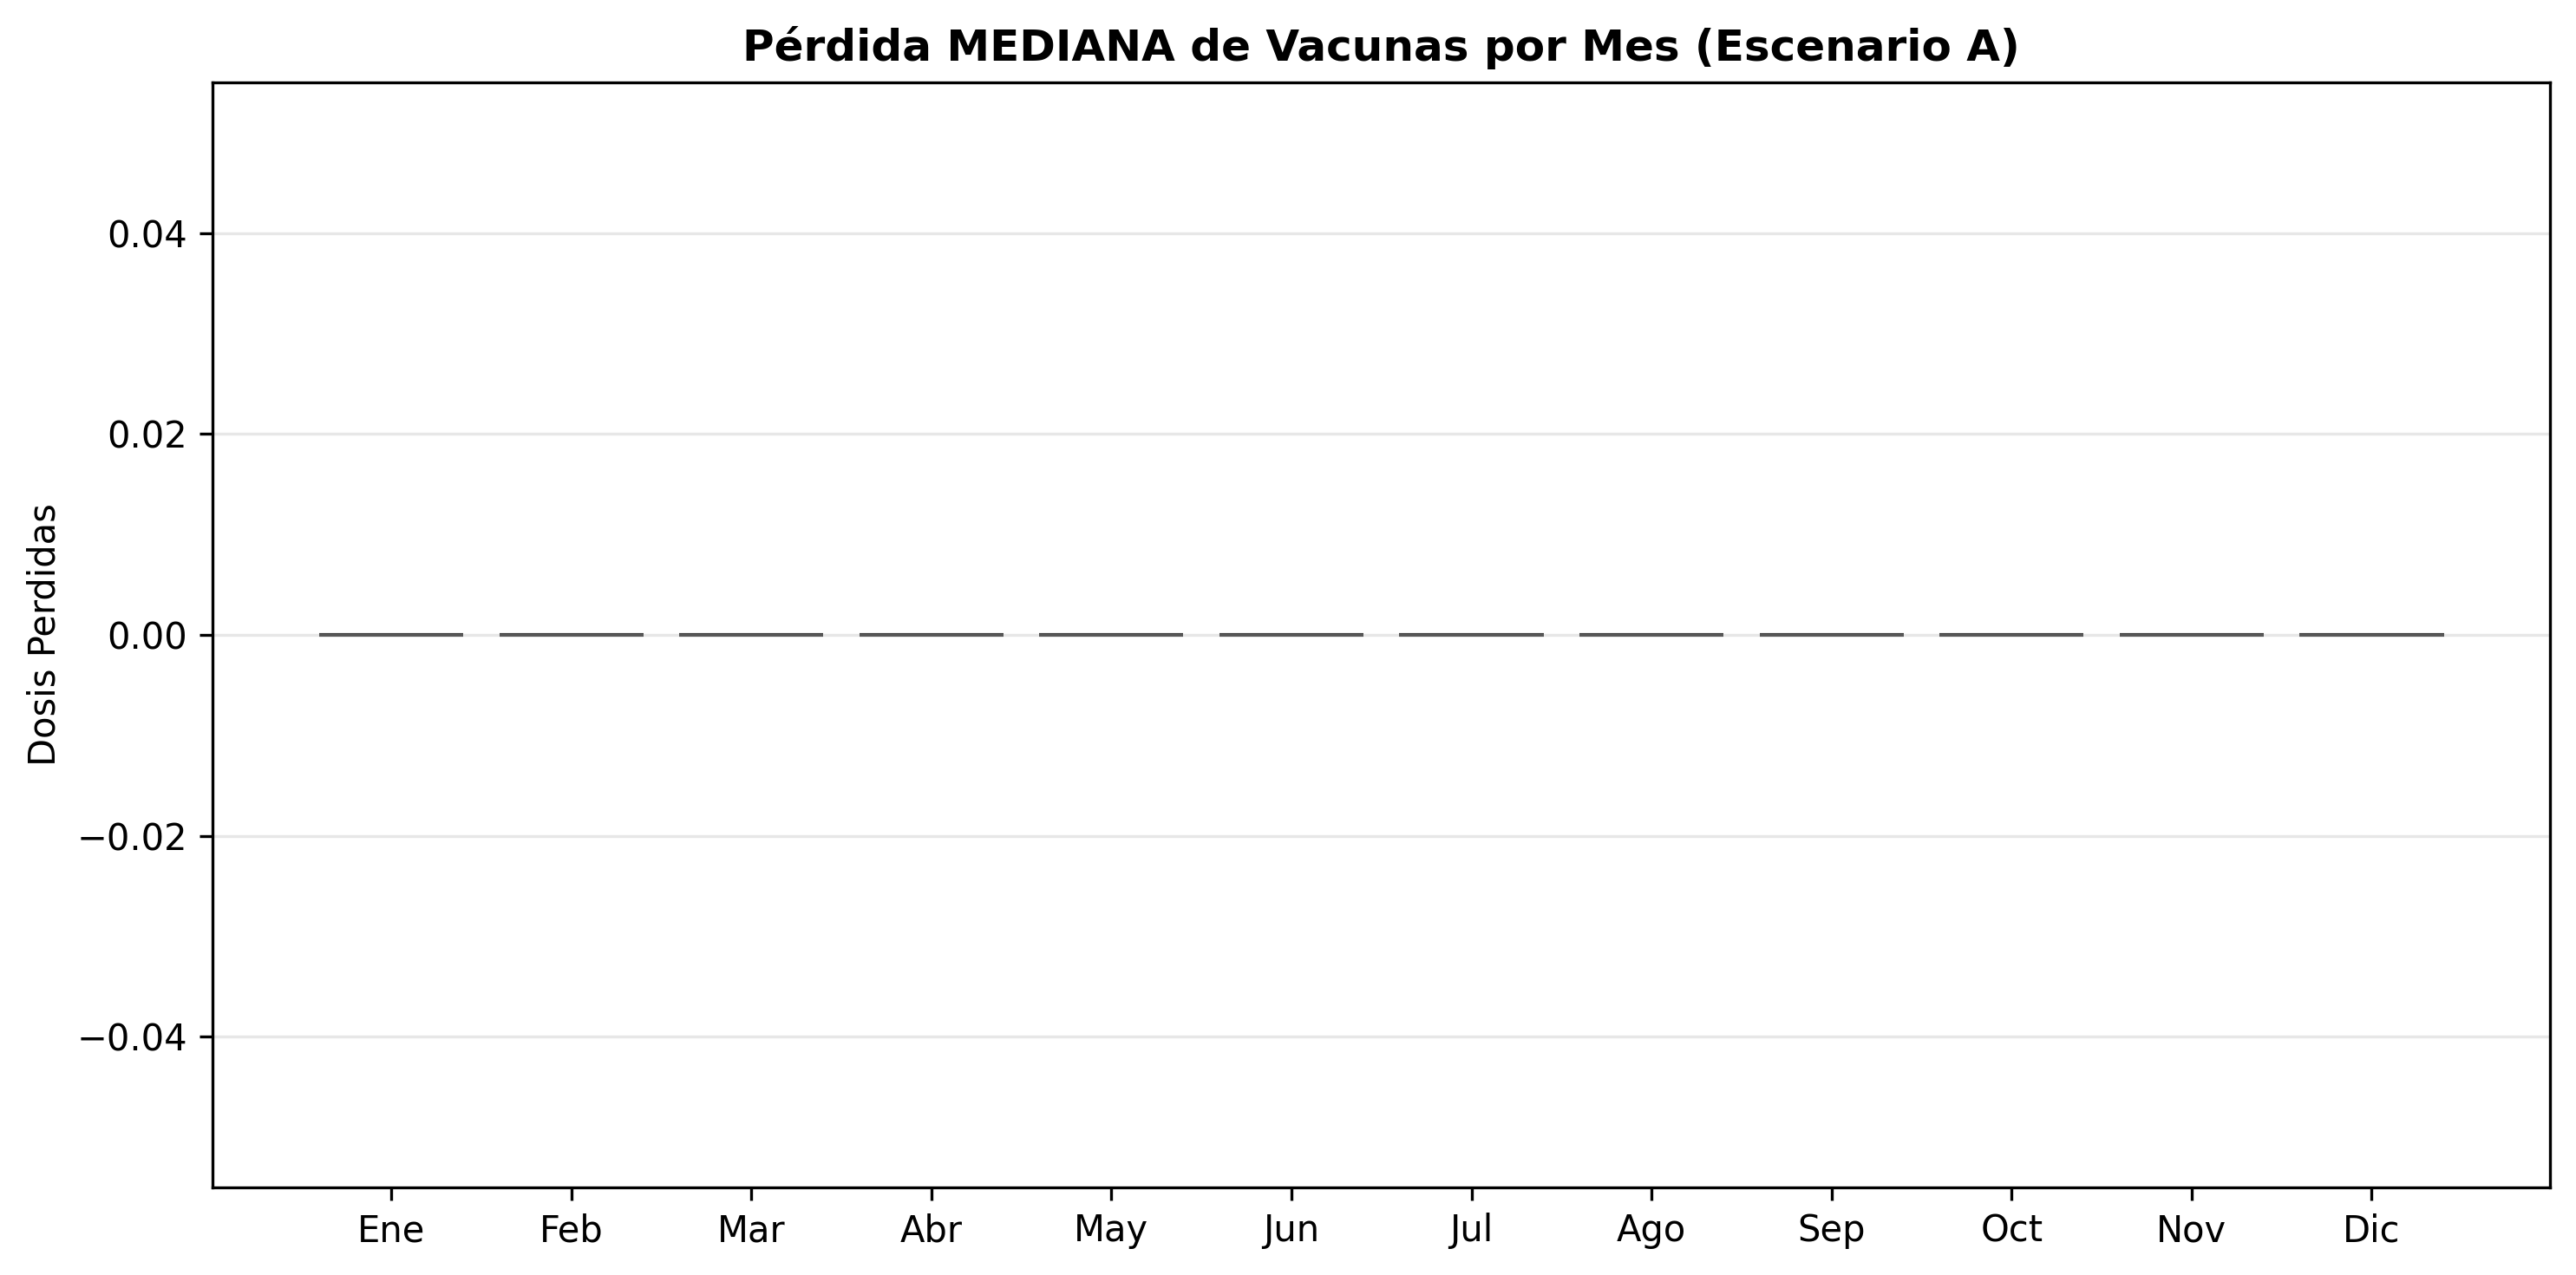

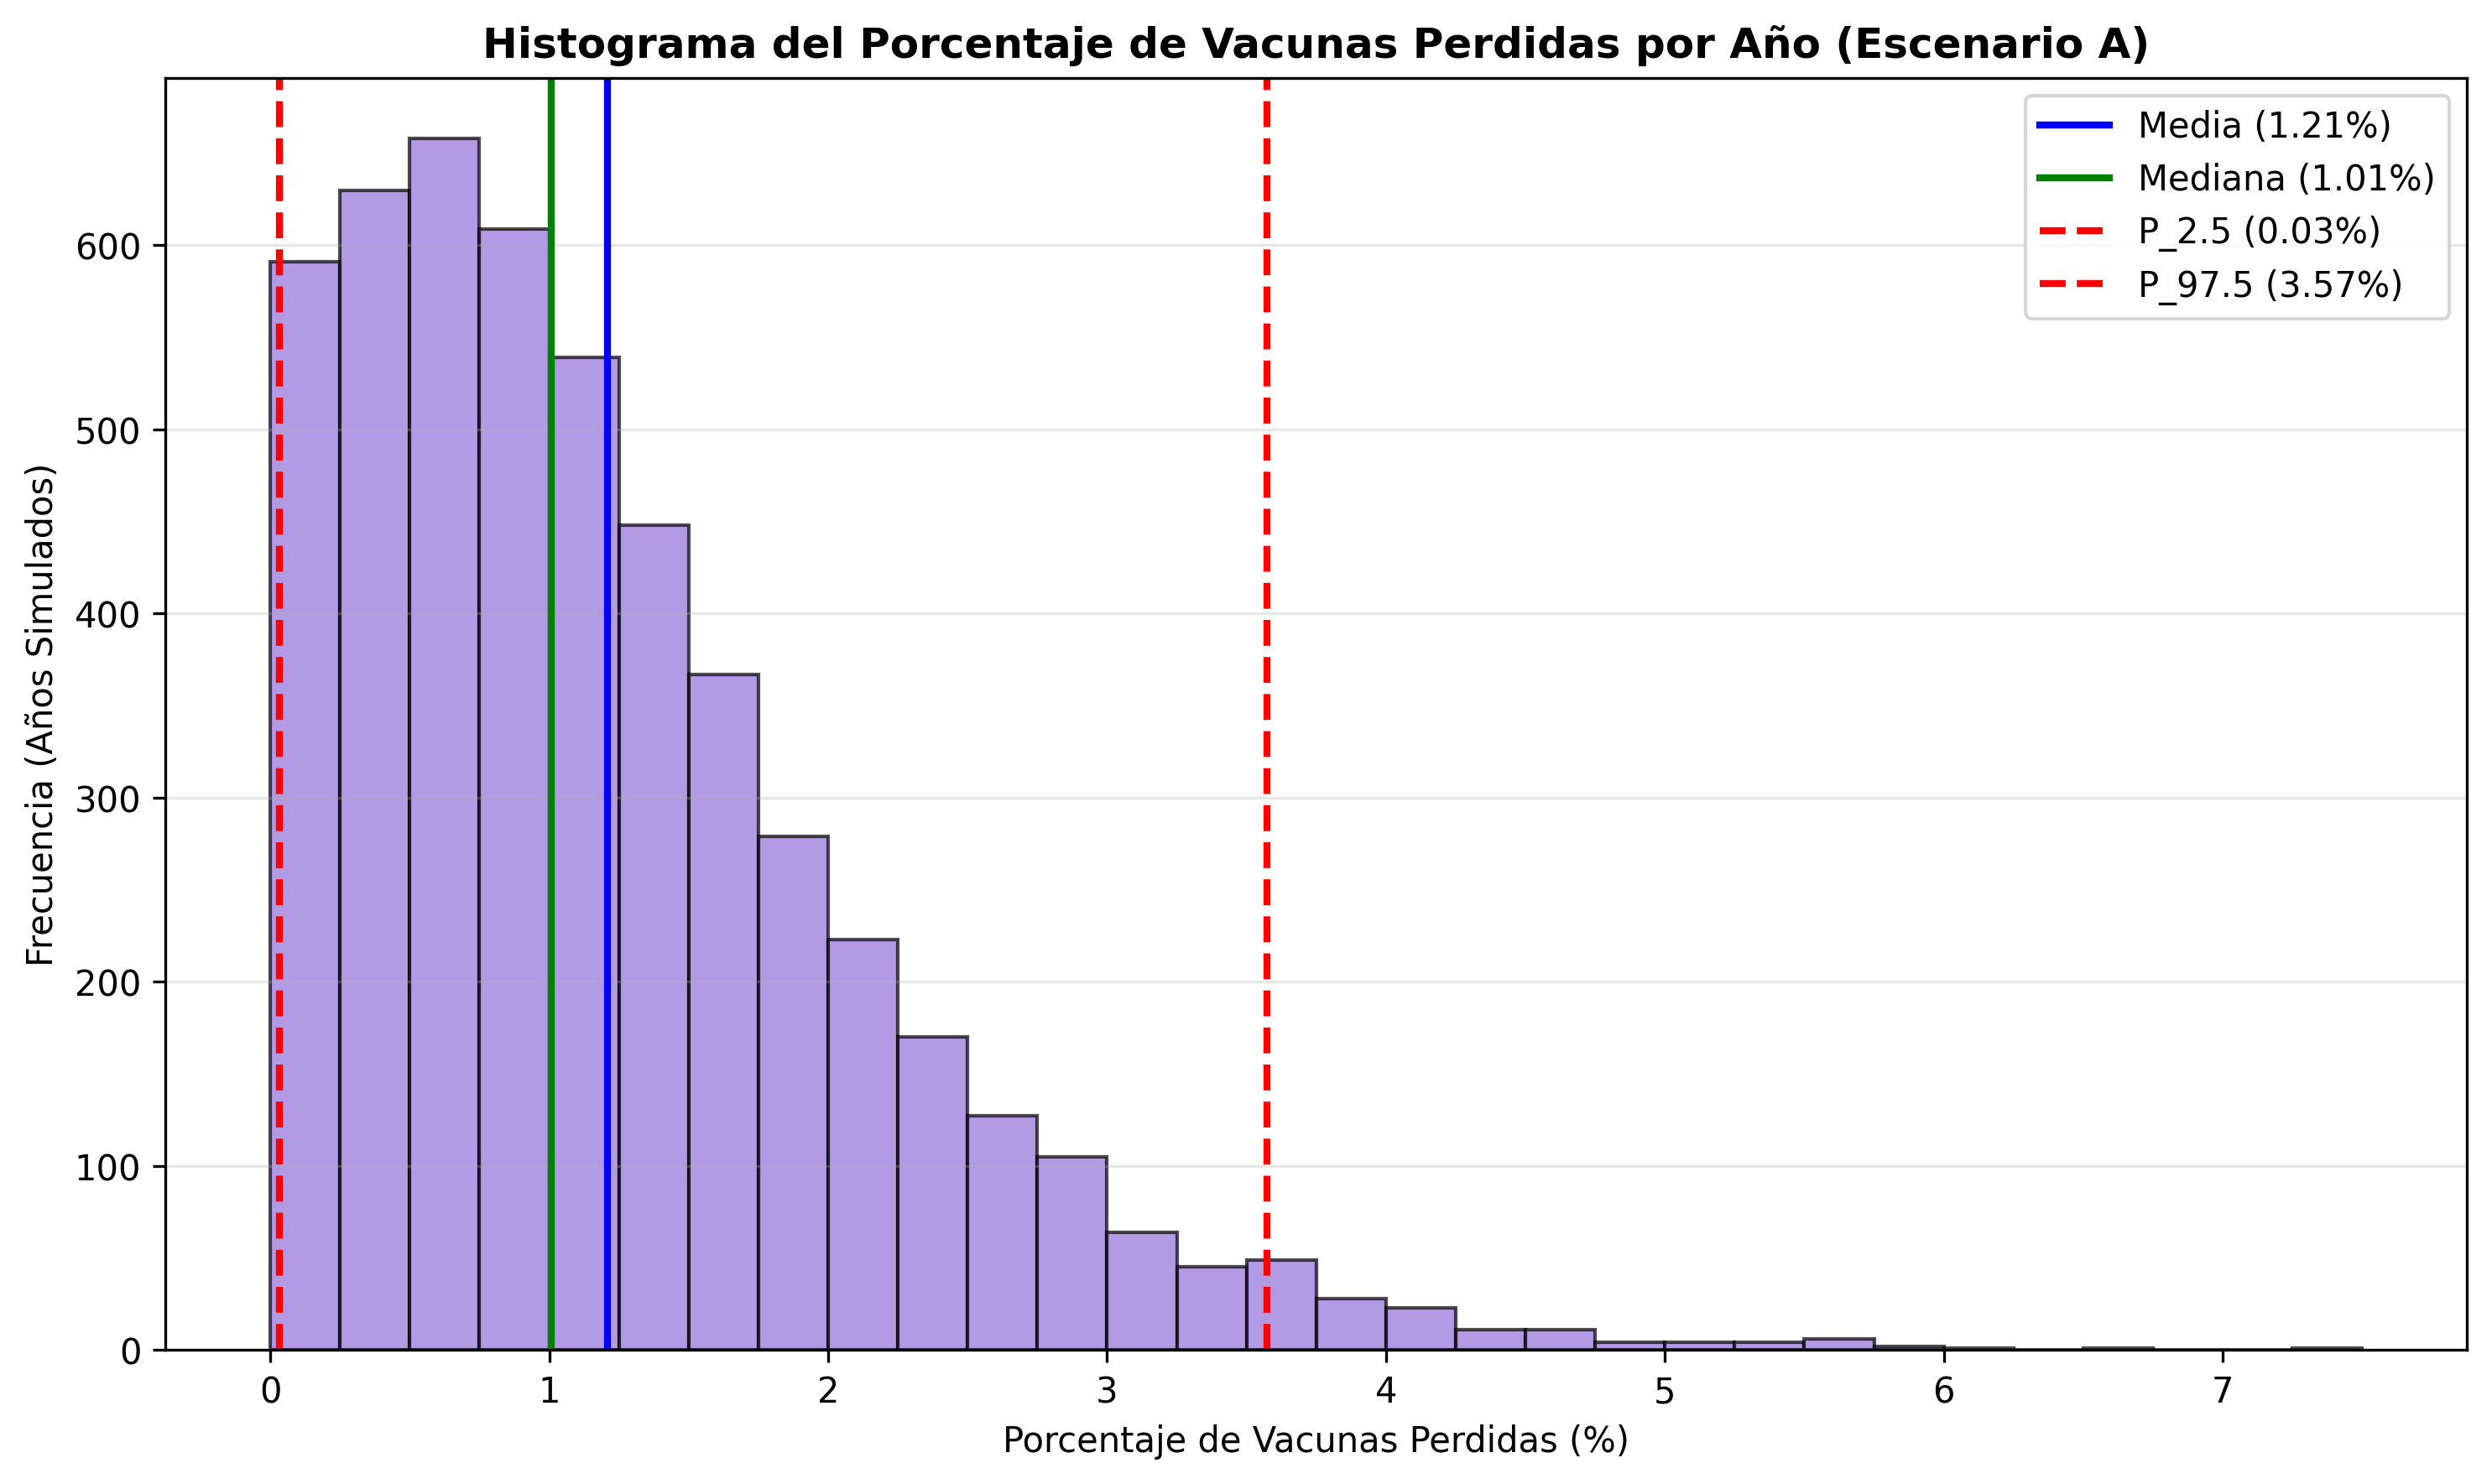

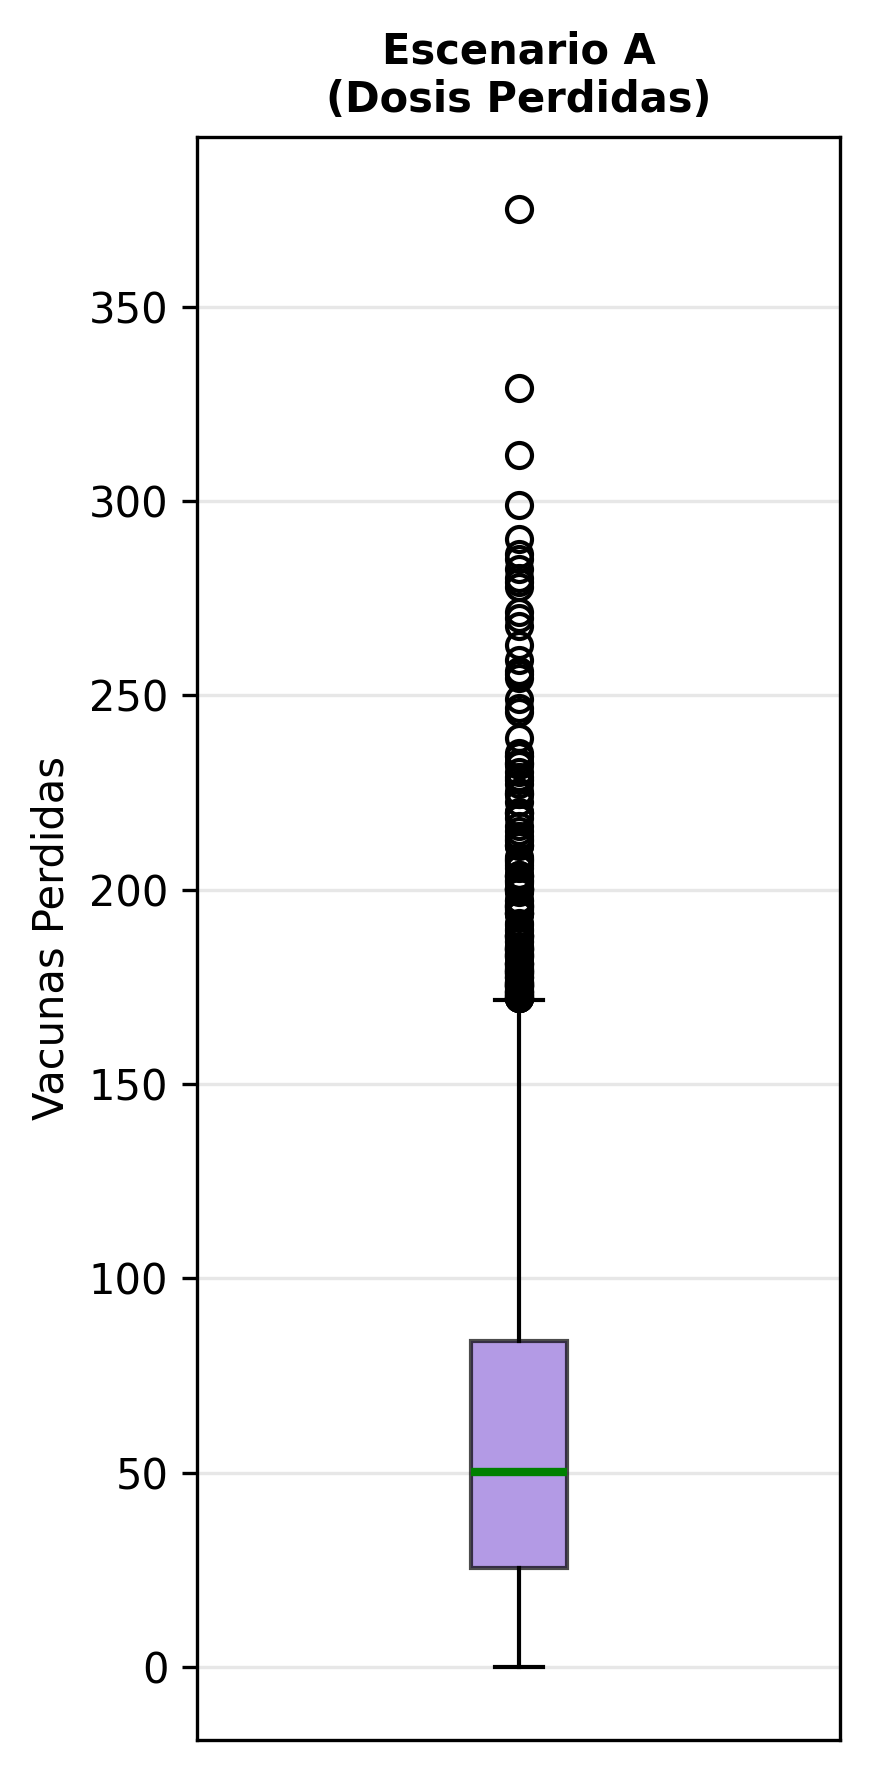

In [ ]:
import warnings
warnings.filterwarnings('ignore') # Ocultar advertencias de medias con arrays vacíos (NaN)

# 1. EXTRAER DATOS A ARREGLOS DE NUMPY
mermas_anuales = np.array([res['merma_anual'] for res in resultados_mc])
dosis_ingresadas = np.array([res['dosis_totales_ingresadas'] for res in resultados_mc])
apagones_anuales = np.array([res['total_apagones'] for res in resultados_mc])
aperturas_anuales = np.array([res['total_aperturas'] for res in resultados_mc])
mermas_mensuales = np.array([res['merma_por_mes'] for res in resultados_mc])

# Termodinámica
horas_8 = np.array([res['horas_8'] for res in resultados_mc])
horas_2 = np.array([res['horas_2'] for res in resultados_mc])
horas_0 = np.array([res['horas_0'] for res in resultados_mc])
ph_8 = np.array([res['porcentaje_horas_8'] for res in resultados_mc])
ph_2 = np.array([res['porcentaje_horas_2'] for res in resultados_mc])
ph_0 = np.array([res['porcentaje_horas_0'] for res in resultados_mc])
ev_8 = np.array([res['eventos_8'] for res in resultados_mc])
ev_2 = np.array([res['eventos_2'] for res in resultados_mc])
ev_0 = np.array([res['eventos_0'] for res in resultados_mc])
dia_8 = np.array([res['primer_dia_8'] for res in resultados_mc])
dia_2 = np.array([res['primer_dia_2'] for res in resultados_mc])
dia_0 = np.array([res['primer_dia_0'] for res in resultados_mc])

porcentajes_perdida = np.array([res['porcentaje_perdida'] for res in resultados_mc])

horas_totales = horas_8 + horas_2
ph_totales = ph_8 + ph_2

# 2. TABLA RESUMEN EN CONSOLA
print("="*75)
print(" TABLA RESUMEN DE RIESGO OPERATIVO Y TERMODINÁMICO (ESCENARIO A) ")
print("="*75)
print(f"Trayectorias Simuladas: {N_SIMULACIONES} años")
print(f"Apagones promedio: {np.mean(apagones_anuales):.1f} por año")
print(f"Aperturas promedio: {np.mean(aperturas_anuales):.0f} por año")
print("-" * 75)
print("MÉTRICAS TERMODINÁMICAS (Excursiones Térmicas)")

print(f"\n -> EXCURSIONES SOBRE 8°C:")
print(f"    Eventos anuales  : Promedio {np.mean(ev_8):.1f} | Mediana {np.median(ev_8):.0f} | Int. 95% [{np.percentile(ev_8, 2.5):.0f}, {np.percentile(ev_8, 97.5):.0f}]")
print(f"    Tiempo acumulado : Promedio {np.mean(horas_8):.1f} h ({np.mean(ph_8):.2f}%) | Mediana {np.median(horas_8):.1f} h ({np.median(ph_8):.2f}%) | Int. 95% [{np.percentile(horas_8, 2.5):.1f} h, {np.percentile(horas_8, 97.5):.1f} h]")
if not np.all(np.isnan(dia_8)):
    print(f"    Primer registro  : Promedio Día {np.nanmean(dia_8):.0f} | Mediana Día {np.nanmedian(dia_8):.0f} | Int. 95% [Día {np.nanpercentile(dia_8, 2.5):.0f}, Día {np.nanpercentile(dia_8, 97.5):.0f}]")

print(f"\n -> EXCURSIONES BAJO 2°C:")
print(f"    Eventos anuales  : Promedio {np.mean(ev_2):.1f} | Mediana {np.median(ev_2):.0f} | Int. 95% [{np.percentile(ev_2, 2.5):.0f}, {np.percentile(ev_2, 97.5):.0f}]")
print(f"    Tiempo acumulado : Promedio {np.mean(horas_2):.1f} h ({np.mean(ph_2):.2f}%) | Mediana {np.median(horas_2):.1f} h ({np.median(ph_2):.2f}%) | Int. 95% [{np.percentile(horas_2, 2.5):.1f} h, {np.percentile(horas_2, 97.5):.1f} h]")
if not np.all(np.isnan(dia_2)):
    print(f"    Primer registro  : Promedio Día {np.nanmean(dia_2):.0f} | Mediana Día {np.nanmedian(dia_2):.0f} | Int. 95% [Día {np.nanpercentile(dia_2, 2.5):.0f}, Día {np.nanpercentile(dia_2, 97.5):.0f}]")

print(f"\n -> CONGELACIÓN (BAJO 0°C):")
print(f"    Eventos anuales  : Promedio {np.mean(ev_0):.1f} | Mediana {np.median(ev_0):.0f} | Int. 95% [{np.percentile(ev_0, 2.5):.0f}, {np.percentile(ev_0, 97.5):.0f}]")
print(f"    Tiempo acumulado : Promedio {np.mean(horas_0):.1f} h ({np.mean(ph_0):.2f}%) | Mediana {np.median(horas_0):.1f} h ({np.median(ph_0):.2f}%) | Int. 95% [{np.percentile(horas_0, 2.5):.1f} h, {np.percentile(horas_0, 97.5):.1f} h]")
if not np.all(np.isnan(dia_0)):
    print(f"    Primer registro  : Promedio Día {np.nanmean(dia_0):.0f} | Mediana Día {np.nanmedian(dia_0):.0f} | Int. 95% [Día {np.nanpercentile(dia_0, 2.5):.0f}, Día {np.nanpercentile(dia_0, 97.5):.0f}]")

print(f"\n => TIEMPO TOTAL FUERA DE RANGO NORMATIVO (>8°C y <2°C):")
print(f"    Tiempo acumulado : Promedio {np.mean(horas_totales):.1f} h ({np.mean(ph_totales):.2f}%) | Mediana {np.median(horas_totales):.1f} h ({np.median(ph_totales):.2f}%) | Int. 95% [{np.percentile(horas_totales, 2.5):.1f} h, {np.percentile(horas_totales, 97.5):.1f} h]")

print("-" * 75)
print("MÉTRICAS LOGÍSTICAS Y DE RIESGO")
print(f" Dosis Perdidas : Promedio {np.mean(mermas_anuales):.0f} | Mediana {np.median(mermas_anuales):.0f} | Int. 95% [{np.percentile(mermas_anuales, 2.5):.0f}, {np.percentile(mermas_anuales, 97.5):.0f}] dosis")
print(f" Merma Relativa : Promedio {np.mean(porcentajes_perdida):.2f}% | Mediana {np.median(porcentajes_perdida):.2f}% | Int. 95% [{np.percentile(porcentajes_perdida, 2.5):.2f}%, {np.percentile(porcentajes_perdida, 97.5):.2f}%]")
print("="*75)

# 3. GRÁFICAS (5 PANELES SEPARADOS)

# --- GRÁFICA 1: TRAYECTORIAS (30) ---
plt.figure(figsize=(10, 5), dpi=300)
trayectorias_a_graficar = 30
for i in range(trayectorias_a_graficar):
    plt.plot(t_horas/24, resultados_mc[i]['trayectoria_merma'], alpha=0.4, linewidth=1.2)
plt.title(f'Pérdidas de Dosis: Escenario A (30 trayectorias)', fontweight='bold')
plt.xlabel('Días del año')
plt.ylabel('Vacunas Perdidas (Dosis)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('abanico_riesgo_escenario_A.png', bbox_inches='tight', dpi=300)
plt.show()

# --- GRÁFICA 2: PROMEDIO MENSUAL DE MERMAS ---
plt.figure(figsize=(10, 5), dpi=300)
meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
plt.bar(meses_labels, np.mean(mermas_mensuales, axis=0), color='skyblue', alpha=0.8, edgecolor='black')
plt.title('Pérdida PROMEDIO de Vacunas por Mes (Escenario A)', fontweight='bold')
plt.ylabel('Dosis Perdidas')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('barras_estacionales_promedio_escenario_A.png', bbox_inches='tight', dpi=300)
plt.show()

# --- GRÁFICA 3: MEDIANA MENSUAL DE MERMAS ---
plt.figure(figsize=(10, 5), dpi=300)
plt.bar(meses_labels, np.median(mermas_mensuales, axis=0), color='skyblue', alpha=0.8, edgecolor='black')
plt.title('Pérdida MEDIANA de Vacunas por Mes (Escenario A)', fontweight='bold')
plt.ylabel('Dosis Perdidas')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('barras_estacionales_mediana_escenario_A.png', bbox_inches='tight', dpi=300)
plt.show()

# --- GRÁFICA 4: HISTOGRAMA DE RIESGO ---
plt.figure(figsize=(10, 6), dpi=300)
plt.hist(porcentajes_perdida, bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(porcentajes_perdida), color='blue', linestyle='-', linewidth=2, label=f'Media ({np.mean(porcentajes_perdida):.2f}%)')
plt.axvline(np.median(porcentajes_perdida), color='green', linestyle='-', linewidth=2, label=f'Mediana ({np.median(porcentajes_perdida):.2f}%)')
plt.axvline(np.percentile(porcentajes_perdida, 2.5), color='red', linestyle='--', linewidth=2, label=f'P_2.5 ({np.percentile(porcentajes_perdida, 2.5):.2f}%)')
plt.axvline(np.percentile(porcentajes_perdida, 97.5), color='red', linestyle='--', linewidth=2, label=f'P_97.5 ({np.percentile(porcentajes_perdida, 97.5):.2f}%)')
plt.title('Histograma del Porcentaje de Vacunas Perdidas por Año (Escenario A)', fontweight='bold')
plt.xlabel('Porcentaje de Vacunas Perdidas (%)')
plt.ylabel('Frecuencia (Años Simulados)')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('histograma_porcentajes_escenario_A.png', bbox_inches='tight', dpi=300)
plt.show()

# --- GRÁFICA 5: BOXPLOT ANGOSTO DE DOSIS PERDIDAS ---
plt.figure(figsize=(3, 6), dpi=300)
plt.boxplot(mermas_anuales, patch_artist=True, boxprops=dict(facecolor='mediumpurple', color='black', alpha=0.7), medianprops=dict(color='green', linewidth=2))
plt.title('Escenario A\n(Dosis Perdidas)', fontweight='bold', fontsize=10)
plt.ylabel('Vacunas Perdidas')
plt.grid(axis='y', alpha=0.3)
plt.xticks([])
plt.tight_layout()
plt.savefig('boxplot_angosto_escenario_A.png', bbox_inches='tight', dpi=300)
plt.show()

## Celda 9: Análisis de Distribuciones y Prueba de Normalidad (Línea Base)

En esta celda evaluamos la naturaleza estadística del riesgo. En el cálculo estocástico, comprender la "forma" de las distribuciones resultantes es tan importante como conocer sus promedios.

Aplicamos la **Prueba de Shapiro-Wilk** a las métricas termodinámicas y logísticas obtenidas del Montecarlo. Esta prueba nos permite evaluar matemáticamente la hipótesis nula ($H_0$) de que los datos provienen de una distribución Normal (Gaussiana).
* Si el **Valor-p < 0.05**, rechazamos $H_0$, concluyendo que la distribución es asimétrica y depende de eventos extremos (colas pesadas).
* Si el **Valor-p > 0.05**, no rechazamos $H_0$, lo que sugiere que la variable se ha estabilizado gracias a la suma de múltiples factores aleatorios (Teorema del Límite Central).

En este escenario de inactividad, esperamos una fuerte asimetría debido a la dependencia directa de eventos poco frecuentes (apagones mayores).

In [ ]:
import scipy.stats as stats
import pandas as pd

# 1. PREPARACIÓN DE LAS VARIABLES (Filtrando NaNs para las pruebas)
variables_a_testear = {
    "Dosis Perdidas": mermas_anuales,
    "Porcentaje de Merma": porcentajes_perdida,
    "Eventos > 8°C": ev_8,
    "Horas Acumuladas > 8°C": horas_8,
    "Primer Día > 8°C": dia_8[~np.isnan(dia_8)],
    "Eventos < 2°C": ev_2,
    "Horas Acumuladas < 2°C": horas_2,
    "Primer Día < 2°C": dia_2[~np.isnan(dia_2)],
    "Eventos < 0°C": ev_0,
    "Horas Acumuladas < 0°C": horas_0,
    "Primer Día < 0°C": dia_0[~np.isnan(dia_0)],
    "Tiempo Total Fuera de Rango": horas_totales
}

resultados_test = []

# 2. PRUEBA DE SHAPIRO-WILK
for nombre, data in variables_a_testear.items():
    # Solo aplicamos el test si hay datos suficientes y la varianza no es cero
    if len(data) >= 3 and np.var(data) > 0:
        stat, p_value = stats.shapiro(data)
        # Nivel de significancia alfa = 0.05
        es_normal = "Sí (No se rechaza H0)" if p_value > 0.05 else "No (Se rechaza H0)"
    else:
        stat, p_value = np.nan, np.nan
        es_normal = "No evaluable (Constante o Vacío)"

    resultados_test.append({
        "Métrica": nombre,
        "Estadístico W": stat,
        "Valor-p": p_value,
        "¿Distribución Normal?": es_normal
    })

# 3. IMPRESIÓN DE LA TABLA
df_normalidad = pd.DataFrame(resultados_test)

print("="*85)
print(" PRUEBA DE NORMALIDAD DE SHAPIRO-WILK (ESCENARIO A) ")
print("="*85)
print(df_normalidad.to_string(index=False, float_format=lambda x: f"{x:.4e}" if pd.notnull(x) else "N/A"))
print("="*85)
print("* Nivel de significancia (α) = 0.05")

 PRUEBA DE NORMALIDAD DE SHAPIRO-WILK (ESCENARIO A) 
                    Métrica  Estadístico W    Valor-p ¿Distribución Normal?
             Dosis Perdidas     9.0423e-01 1.7427e-48    No (Se rechaza H0)
        Porcentaje de Merma     9.0423e-01 1.7427e-48    No (Se rechaza H0)
              Eventos > 8°C     9.7850e-01 7.3588e-27    No (Se rechaza H0)
     Horas Acumuladas > 8°C     9.4834e-01 9.5700e-39    No (Se rechaza H0)
           Primer Día > 8°C     8.1727e-01 6.7788e-60    No (Se rechaza H0)
              Eventos < 2°C     9.7886e-01 1.1876e-26    No (Se rechaza H0)
     Horas Acumuladas < 2°C     9.5410e-01 5.2258e-37    No (Se rechaza H0)
           Primer Día < 2°C     8.1328e-01 2.6841e-60    No (Se rechaza H0)
              Eventos < 0°C     2.8862e-02 3.6845e-95    No (Se rechaza H0)
     Horas Acumuladas < 0°C     2.6188e-02 3.1730e-95    No (Se rechaza H0)
           Primer Día < 0°C     9.0327e-01 2.9540e-02    No (Se rechaza H0)
Tiempo Total Fuera de Rango     9.7

## Celda 10: Remuestreo Bootstrap y Análisis No Paramétrico (Línea Base)

Debido a que la prueba de Shapiro-Wilk rechazó la normalidad de nuestras distribuciones de riesgo (las cuales presentan asimetría y colas pesadas por los eventos extremos), la estadística inferencial clásica no es aplicable.

Para resolver esto de forma rigurosa, implementamos el método no paramétrico de **Bootstrap**.
1. **Remuestreo:** Extraemos 10,000 muestras aleatorias (con reemplazo) a partir de nuestros 5,000 años simulados.
2. **Intervalos de Confianza:** Por el Teorema del Límite Central, la distribución de estas 10,000 medias muestrales convergerá a una distribución Normal perfecta. Esto nos permite extraer el Intervalo de Confianza al 95% para afirmar con absoluta certeza en qué rangos operará el centro de almacenamiento para vacunas.
3. **Visualización Estabilizada:** Generaremos el histograma de las medias (para validar visualmente la normalidad del estimador) y un *boxplot* de las medias, demostrando cómo se reduce drásticamente la incertidumbre de los datos atípicos.

Ejecutando remuestreo Bootstrap (10000 iteraciones)...
Bootstrap completado en 4.30 segundos.

 TABLA INFERENCIAL BOOTSTRAP: PROMEDIOS ESPERADOS E INTERVALOS AL 95% (ESCENARIO A) 
 -> EXCURSIONES SOBRE 8°C:
    Eventos anuales  : Promedio 26.4 | Mediana 25 | Int. Conf 95% [26.1, 26.7]
    Tiempo acumulado : Promedio 12.6 h (0.14%) | Mediana 11.4 h (0.13%) | Int. Conf 95% [12.4 h (0.14%), 12.8 h (0.15%)]
    Primer registro  : Promedio Día 38 | Mediana Día 26 | Int. Conf 95% [Día 37, Día 39]

 -> EXCURSIONES BAJO 2°C:
    Eventos anuales  : Promedio 25.2 | Mediana 24 | Int. Conf 95% [24.9, 25.5]
    Tiempo acumulado : Promedio 11.8 h (0.13%) | Mediana 10.8 h (0.12%) | Int. Conf 95% [11.7 h (0.13%), 12.0 h (0.14%)]
    Primer registro  : Promedio Día 38 | Mediana Día 27 | Int. Conf 95% [Día 37, Día 39]

 -> CONGELACIÓN (BAJO 0°C):
    Años con eventos : El biológico se congeló en 23 de los 5000 años simulados (0.46%)
    Eventos anuales  : Promedio 0.01 | Mediana 0 | Int. Conf 95% [0.01,

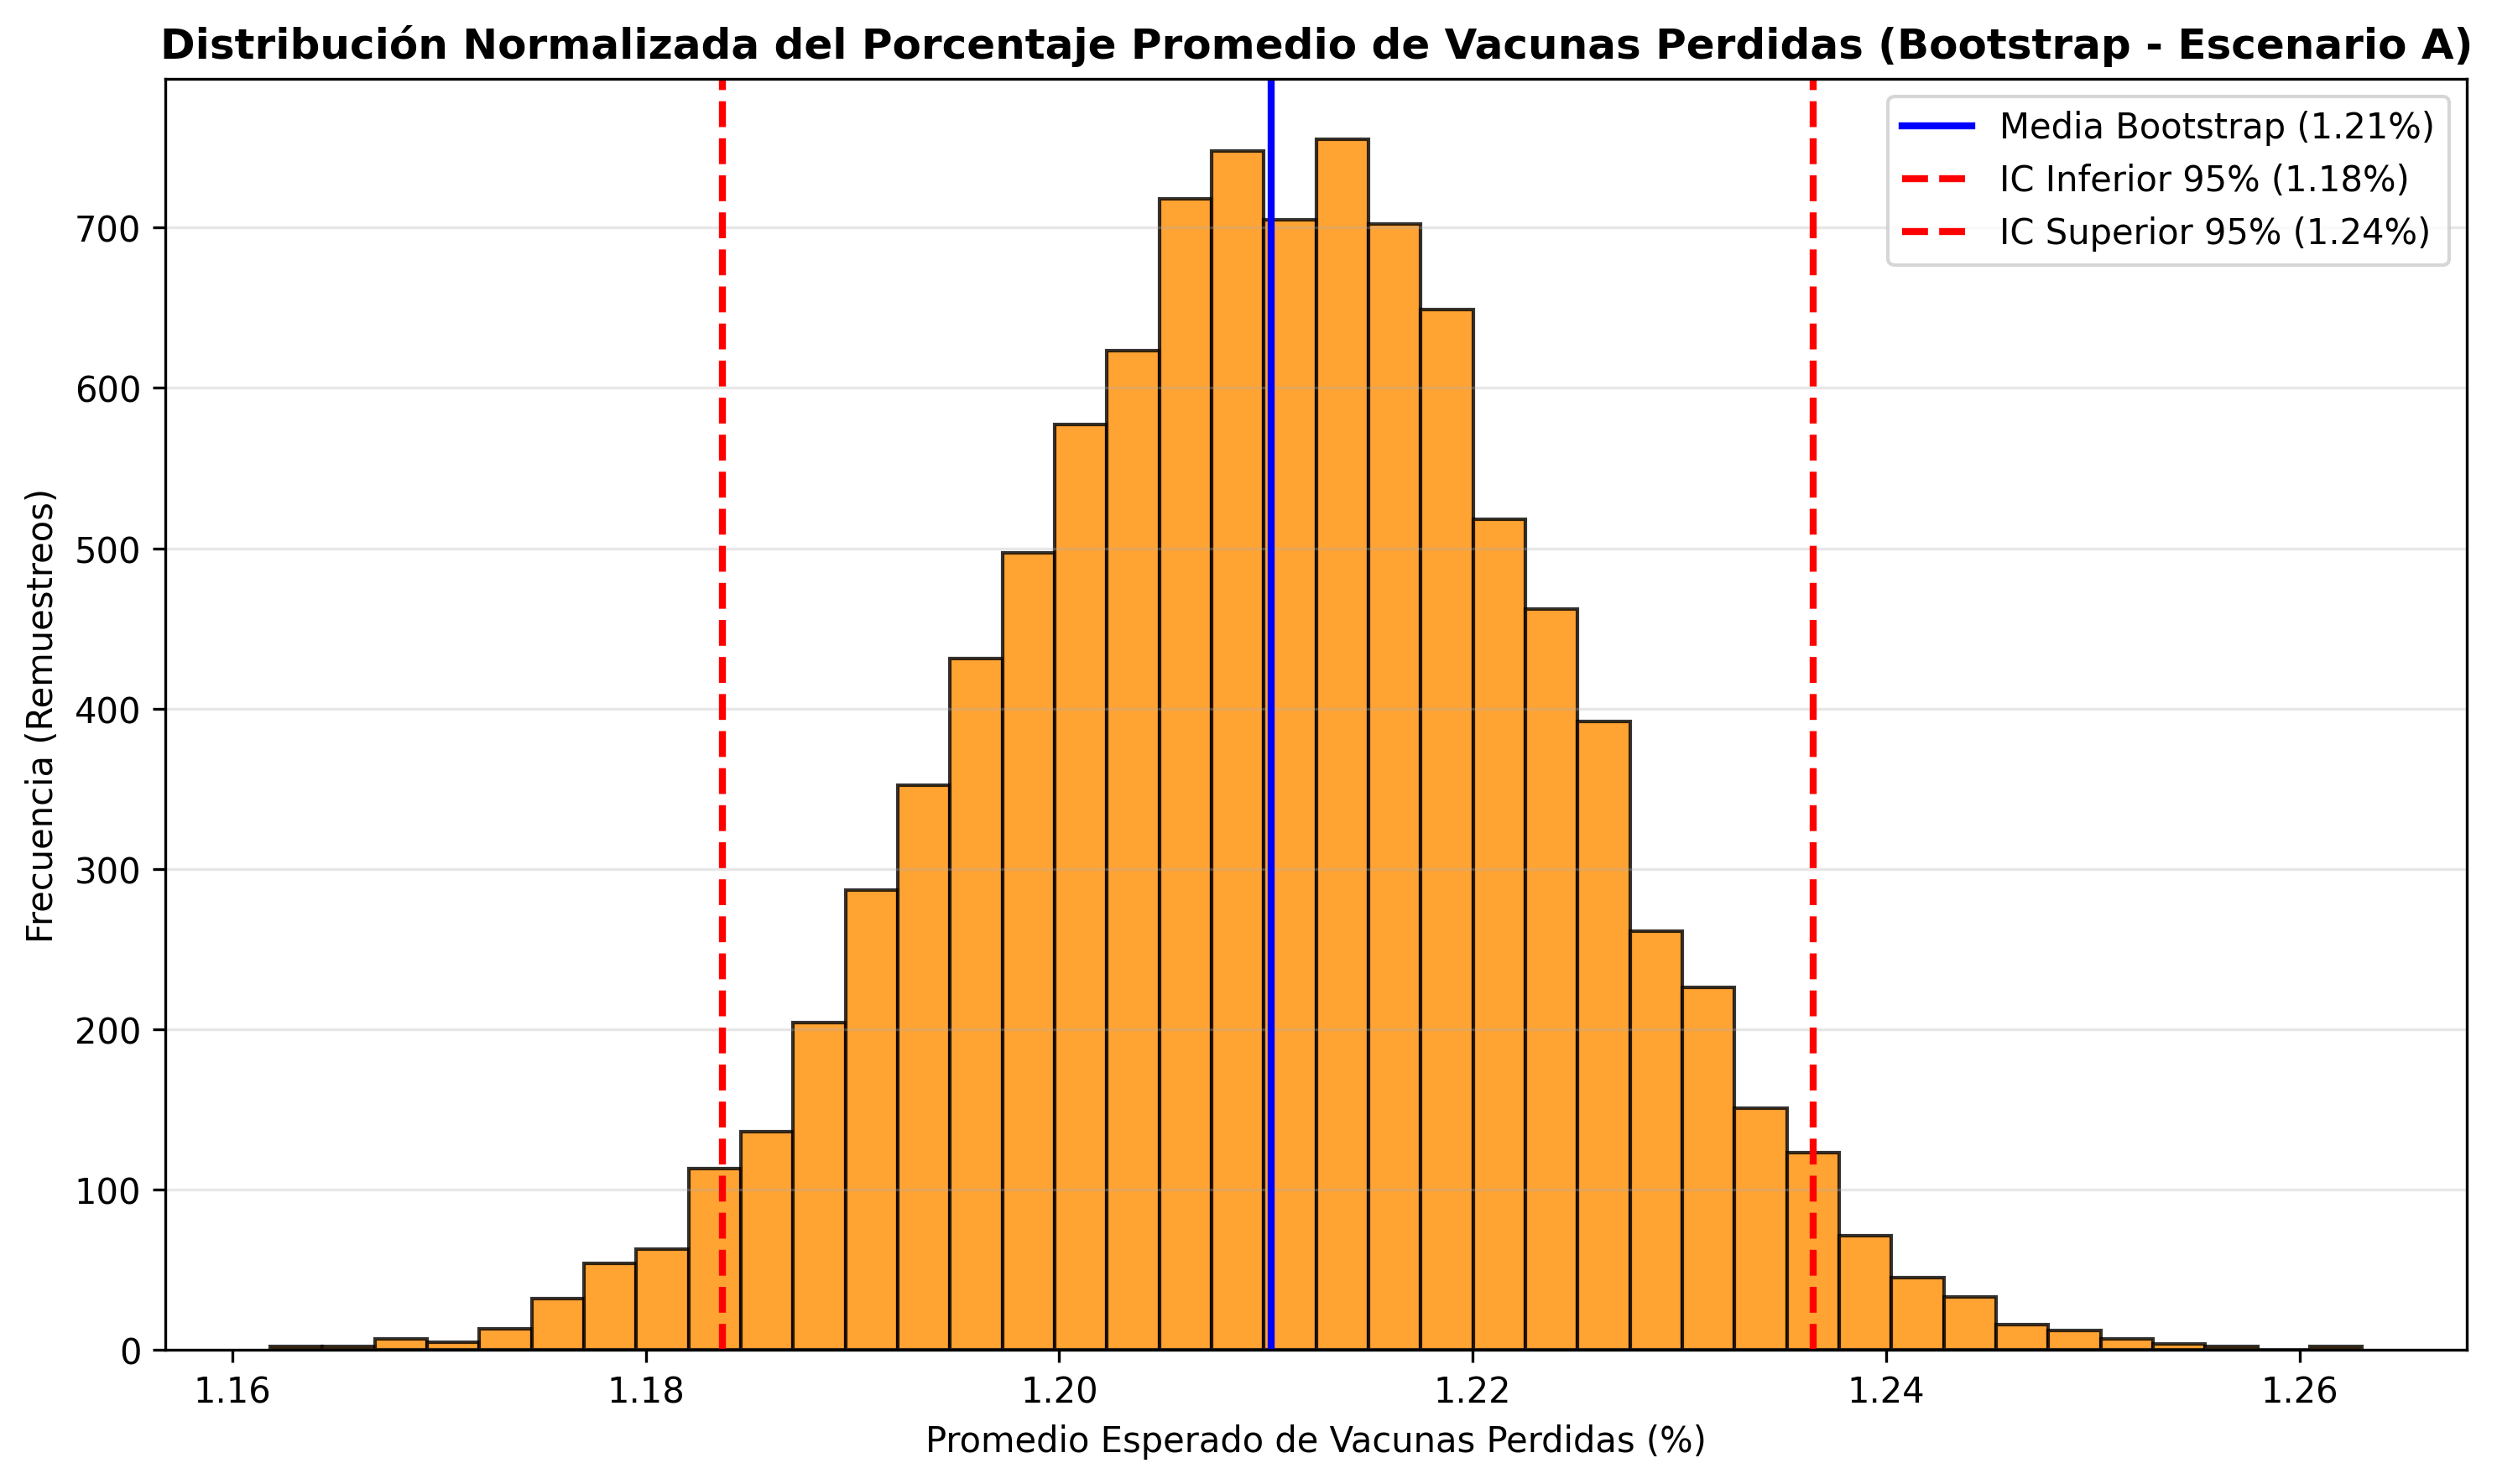

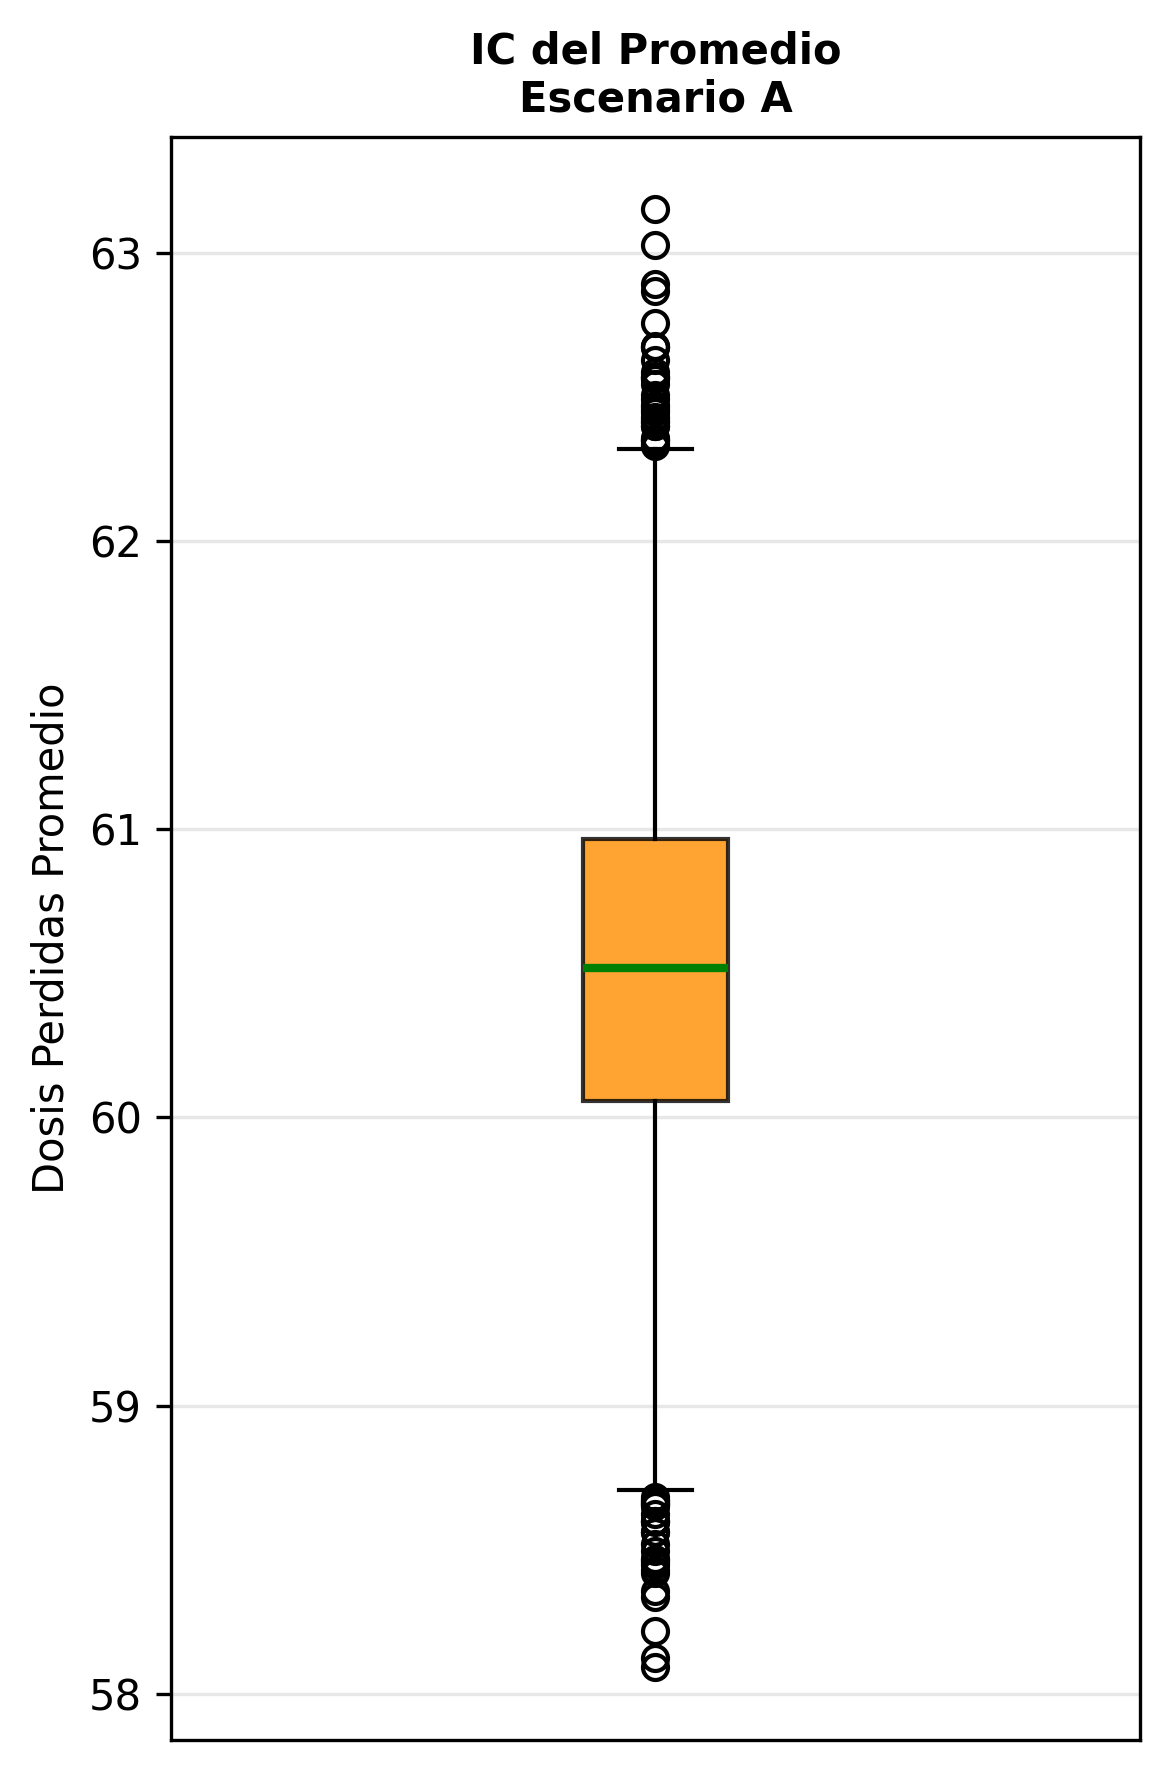

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings

# 1. PREPARACIÓN DEL BOOTSTRAP
np.random.seed(42)
N_BOOT = 10000
n_size = len(mermas_anuales)

print(f"Ejecutando remuestreo Bootstrap ({N_BOOT} iteraciones)...")
inicio_boot = time.time()

# Remuestreo vectorizado (Extremadamente rápido)
idx = np.random.randint(0, n_size, (N_BOOT, n_size))

# 2. CÁLCULO DE MEDIAS BOOTSTRAP
boot_ev_8 = np.mean(ev_8[idx], axis=1)
boot_h_8 = np.mean(horas_8[idx], axis=1)
boot_ph_8 = np.mean(ph_8[idx], axis=1)

boot_ev_2 = np.mean(ev_2[idx], axis=1)
boot_h_2 = np.mean(horas_2[idx], axis=1)
boot_ph_2 = np.mean(ph_2[idx], axis=1)

boot_ev_0 = np.mean(ev_0[idx], axis=1)
boot_h_0 = np.mean(horas_0[idx], axis=1)
boot_ph_0 = np.mean(ph_0[idx], axis=1)

boot_htot = np.mean(horas_totales[idx], axis=1)
boot_phtot = np.mean(ph_totales[idx], axis=1)

boot_mermas = np.mean(mermas_anuales[idx], axis=1)
boot_pct_perdida = np.mean(porcentajes_perdida[idx], axis=1)

# Para los días (ignoramos NaNs de los años donde no hubo fallas)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    boot_dia_8 = np.nanmean(dia_8[idx], axis=1)
    boot_dia_2 = np.nanmean(dia_2[idx], axis=1)
    boot_dia_0 = np.nanmean(dia_0[idx], axis=1)

print(f"Bootstrap completado en {time.time() - inicio_boot:.2f} segundos.\n")

# 3. TABLA DE RESULTADOS INFERENCIALES (INTERVALOS DE CONFIANZA 95%)
anos_congelacion = np.sum(ev_0 > 0)

print("="*85)
print(" TABLA INFERENCIAL BOOTSTRAP: PROMEDIOS ESPERADOS E INTERVALOS AL 95% (ESCENARIO A) ")
print("="*85)

print(f" -> EXCURSIONES SOBRE 8°C:")
print(f"    Eventos anuales  : Promedio {np.mean(ev_8):.1f} | Mediana {np.median(ev_8):.0f} | Int. Conf 95% [{np.percentile(boot_ev_8, 2.5):.1f}, {np.percentile(boot_ev_8, 97.5):.1f}]")
print(f"    Tiempo acumulado : Promedio {np.mean(horas_8):.1f} h ({np.mean(ph_8):.2f}%) | Mediana {np.median(horas_8):.1f} h ({np.median(ph_8):.2f}%) | Int. Conf 95% [{np.percentile(boot_h_8, 2.5):.1f} h ({np.percentile(boot_ph_8, 2.5):.2f}%), {np.percentile(boot_h_8, 97.5):.1f} h ({np.percentile(boot_ph_8, 97.5):.2f}%)]")
if not np.all(np.isnan(dia_8)):
    print(f"    Primer registro  : Promedio Día {np.nanmean(dia_8):.0f} | Mediana Día {np.nanmedian(dia_8):.0f} | Int. Conf 95% [Día {np.nanpercentile(boot_dia_8, 2.5):.0f}, Día {np.nanpercentile(boot_dia_8, 97.5):.0f}]")

print(f"\n -> EXCURSIONES BAJO 2°C:")
print(f"    Eventos anuales  : Promedio {np.mean(ev_2):.1f} | Mediana {np.median(ev_2):.0f} | Int. Conf 95% [{np.percentile(boot_ev_2, 2.5):.1f}, {np.percentile(boot_ev_2, 97.5):.1f}]")
print(f"    Tiempo acumulado : Promedio {np.mean(horas_2):.1f} h ({np.mean(ph_2):.2f}%) | Mediana {np.median(horas_2):.1f} h ({np.median(ph_2):.2f}%) | Int. Conf 95% [{np.percentile(boot_h_2, 2.5):.1f} h ({np.percentile(boot_ph_2, 2.5):.2f}%), {np.percentile(boot_h_2, 97.5):.1f} h ({np.percentile(boot_ph_2, 97.5):.2f}%)]")
if not np.all(np.isnan(dia_2)):
    print(f"    Primer registro  : Promedio Día {np.nanmean(dia_2):.0f} | Mediana Día {np.nanmedian(dia_2):.0f} | Int. Conf 95% [Día {np.nanpercentile(boot_dia_2, 2.5):.0f}, Día {np.nanpercentile(boot_dia_2, 97.5):.0f}]")

print(f"\n -> CONGELACIÓN (BAJO 0°C):")
print(f"    Años con eventos : El biológico se congeló en {anos_congelacion} de los {n_size} años simulados ({(anos_congelacion/n_size)*100:.2f}%)")
print(f"    Eventos anuales  : Promedio {np.mean(ev_0):.2f} | Mediana {np.median(ev_0):.0f} | Int. Conf 95% [{np.percentile(boot_ev_0, 2.5):.2f}, {np.percentile(boot_ev_0, 97.5):.2f}]")
print(f"    Tiempo acumulado : Promedio {np.mean(horas_0):.2f} h ({np.mean(ph_0):.3f}%) | Mediana {np.median(horas_0):.1f} h ({np.median(ph_0):.2f}%) | Int. Conf 95% [{np.percentile(boot_h_0, 2.5):.2f} h ({np.percentile(boot_ph_0, 2.5):.3f}%), {np.percentile(boot_h_0, 97.5):.2f} h ({np.percentile(boot_ph_0, 97.5):.3f}%)]")
if not np.all(np.isnan(dia_0)):
    print(f"    Primer registro  : Promedio Día {np.nanmean(dia_0):.0f} | Mediana Día {np.nanmedian(dia_0):.0f} | Int. Conf 95% [Día {np.nanpercentile(boot_dia_0, 2.5):.0f}, Día {np.nanpercentile(boot_dia_0, 97.5):.0f}]")

print(f"\n => TIEMPO TOTAL FUERA DE RANGO NORMATIVO (>8°C y <2°C):")
print(f"    Tiempo acumulado : Promedio {np.mean(horas_totales):.1f} h ({np.mean(ph_totales):.2f}%) | Mediana {np.median(horas_totales):.1f} h ({np.median(ph_totales):.2f}%) | Int. Conf 95% [{np.percentile(boot_htot, 2.5):.1f} h ({np.percentile(boot_phtot, 2.5):.2f}%), {np.percentile(boot_htot, 97.5):.1f} h ({np.percentile(boot_phtot, 97.5):.2f}%)]")

print("-" * 85)
print("MÉTRICAS LOGÍSTICAS Y DE RIESGO")
print(f" Dosis Perdidas : Promedio {np.mean(mermas_anuales):.0f} | Mediana {np.median(mermas_anuales):.0f} | Int. Conf 95% [{np.percentile(boot_mermas, 2.5):.0f}, {np.percentile(boot_mermas, 97.5):.0f}] dosis")
print(f" Merma Relativa : Promedio {np.mean(porcentajes_perdida):.2f}% | Mediana {np.median(porcentajes_perdida):.2f}% | Int. Conf 95% [{np.percentile(boot_pct_perdida, 2.5):.2f}%, {np.percentile(boot_pct_perdida, 97.5):.2f}%]")
print("="*85)

# 4. GRÁFICAS DE LOS ESTIMADORES (NORMALIZADOS POR TLC)

# --- GRÁFICA 1: HISTOGRAMA BOOTSTRAP DEL PORCENTAJE ---
plt.figure(figsize=(10, 6), dpi=300)
plt.hist(boot_pct_perdida, bins=40, color='darkorange', edgecolor='black', alpha=0.8)
plt.axvline(np.mean(boot_pct_perdida), color='blue', linestyle='-', linewidth=2, label=f'Media Bootstrap ({np.mean(boot_pct_perdida):.2f}%)')
plt.axvline(np.percentile(boot_pct_perdida, 2.5), color='red', linestyle='--', linewidth=2, label=f'IC Inferior 95% ({np.percentile(boot_pct_perdida, 2.5):.2f}%)')
plt.axvline(np.percentile(boot_pct_perdida, 97.5), color='red', linestyle='--', linewidth=2, label=f'IC Superior 95% ({np.percentile(boot_pct_perdida, 97.5):.2f}%)')

plt.title('Distribución Normalizada del Porcentaje Promedio de Vacunas Perdidas (Bootstrap - Escenario A)', fontweight='bold')
plt.xlabel('Promedio Esperado de Vacunas Perdidas (%)')
plt.ylabel('Frecuencia (Remuestreos)')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('histograma_bootstrap_escenario_A.png', bbox_inches='tight', dpi=300)
plt.show()

# --- GRÁFICA 2: BOXPLOT BOOTSTRAP DE DOSIS PERDIDAS ---
plt.figure(figsize=(4, 6), dpi=300)
plt.boxplot(boot_mermas, patch_artist=True, boxprops=dict(facecolor='darkorange', color='black', alpha=0.8), medianprops=dict(color='green', linewidth=2))
plt.title('IC del Promedio\nEscenario A', fontweight='bold', fontsize=10)
plt.ylabel('Dosis Perdidas Promedio')
plt.grid(axis='y', alpha=0.3)
plt.xticks([])
plt.tight_layout()
plt.savefig('boxplot_bootstrap_escenario_A.png', bbox_inches='tight', dpi=300)
plt.show()